## Dataset: Lượng mưa các trạm đo tại TP.HCM (1995 – 2023)

**Mục tiêu:** Phân tích khám phá dữ liệu mưa theo góc nhìn Data Analyst  
**File nguồn:** `Mua.xls` (53.640 records × 18 cột)

---
### Cấu trúc notebook
1. Data Understanding
2. Data Cleaning & Feature Engineering
3. Univariate Analysis
4. Bivariate & Multivariate Analysis
5. Spatial Analysis
6. Time Series Analysis
7. Outliers & Extreme Events
8. Data Quality by Source & Period
9. Key Insights & Recommendations

## 0. Import thư viện & Cấu hình

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully')

Libraries loaded successfully


---
## 1. Data Understanding – Hiểu cấu trúc & metadata

In [2]:
# Đọc dữ liệu
df = pd.read_excel('../data/raw/Mua.xls', engine='xlrd')

print('Shape:', df.shape)
print(f'   ->{df.shape[0]:,} rows × {df.shape[1]} columns')
print('\nColumns:', df.columns.tolist())
print('\nData types:')
print(df.dtypes)

Shape: (53640, 18)
   ->53,640 rows × 18 columns

Columns: ['FID', 'IDtramMua', 'tenTram', 'capTram', 'viTriTram', 'gio', 'ngay', 'toaDoX', 'toaDoY', 'luongMua', 'maXa', 'maHuyen', 'ghiChu', 'kinhDo', 'viDo', 'day', 'month', 'year']

Data types:
FID                   int64
IDtramMua               str
tenTram                 str
capTram                 str
viTriTram               str
gio                     str
ngay         datetime64[us]
toaDoX                int64
toaDoY                int64
luongMua            float64
maXa                  int64
maHuyen               int64
ghiChu                  str
kinhDo              float64
viDo                float64
day                   int64
month                 int64
year                  int64
dtype: object


In [3]:
# Xem 5 dòng đầu & 5 dòng cuối
print('=== Head ===')
display(df.head())
print('\n=== Tail ===')
display(df.tail())

=== Head ===


,FID,IDtramMua,tenTram,capTram,viTriTram,gio,ngay,toaDoX,toaDoY,luongMua,maXa,maHuyen,ghiChu,kinhDo,viDo,day,month,year
0,0,MUA1,An Phú,,"UBND Xã An Phú, Huyện Củ Chi",,1995-01-25,0,0,0.80,27502,783,Tổng hợp từ số liệu CCTL (Mua - An Phu),106.51,11.11,25,1,1995
1,1,MUA2,An Phú,,"UBND Xã An Phú, Huyện Củ Chi",,1995-01-29,0,0,6.70,27502,783,Tổng hợp từ số liệu CCTL (Mua - An Phu),106.51,11.11,29,1,1995
2,2,MUA3,An Phú,,"UBND Xã An Phú, Huyện Củ Chi",,1995-03-21,0,0,18.10,27502,783,Tổng hợp từ số liệu CCTL (Mua - An Phu),106.51,11.11,21,3,1995
3,3,MUA4,An Phú,,"UBND Xã An Phú, Huyện Củ Chi",,1995-03-26,0,0,49.50,27502,783,Tổng hợp từ số liệu CCTL (Mua - An Phu),106.51,11.11,26,3,1995
4,4,MUA5,An Phú,,"UBND Xã An Phú, Huyện Củ Chi",,1995-04-03,0,0,7.70,27502,783,Tổng hợp từ số liệu CCTL (Mua - An Phu),106.51,11.11,3,4,1995



=== Tail ===


,FID,IDtramMua,tenTram,capTram,viTriTram,gio,ngay,toaDoX,toaDoY,luongMua,maXa,maHuyen,ghiChu,kinhDo,viDo,day,month,year
53635,53635,MUA55252,Thủ Đức,,"Trụ sở khu phố 2 Phường Trường Thọ,",21:20,2023-06-05,0,0,0.20,26827,769,Tổng hợp từ số liệu ĐKTTV (Thống kê mưa theo g...,106.76,10.84,5,6,2023
53636,53636,MUA55253,Thủ Đức,,"Trụ sở khu phố 2 Phường Trường Thọ,",21:40,2023-06-05,0,0,0.20,26827,769,Tổng hợp từ số liệu ĐKTTV (Thống kê mưa theo g...,106.76,10.84,5,6,2023
53637,53637,MUA55254,Thủ Đức,,"Trụ sở khu phố 2 Phường Trường Thọ,",22:10,2023-06-05,0,0,0.20,26827,769,Tổng hợp từ số liệu ĐKTTV (Thống kê mưa theo g...,106.76,10.84,5,6,2023
53638,53638,MUA55255,Thủ Đức,,"Trụ sở khu phố 2 Phường Trường Thọ,",17:10,2023-06-06,0,0,0.20,26827,769,Tổng hợp từ số liệu ĐKTTV (Thống kê mưa theo g...,106.76,10.84,6,6,2023
53639,53639,MUA55256,Thủ Đức,,"Trụ sở khu phố 2 Phường Trường Thọ,",17:20,2023-06-06,0,0,0.20,26827,769,Tổng hợp từ số liệu ĐKTTV (Thống kê mưa theo g...,106.76,10.84,6,6,2023


In [4]:
# Dictionary mô tả cột
column_desc = {
    'FID': 'ID bản ghi (sequential)',
    'IDtramMua': 'Mã trạm mưa (unique identifier)',
    'tenTram': 'Tên trạm đo mưa',
    'capTram': 'Cấp trạm (Ib, IIb, hoặc trống)',
    'viTriTram': 'Vị trí địa lý chi tiết của trạm',
    'gio': 'Giờ đo (có thể trống nếu dữ liệu ngày)',
    'ngay': 'Ngày đo (datetime)',
    'toaDoX': 'Tọa độ X (hầu hết = 0 → không dùng được)',
    'toaDoY': 'Tọa độ Y (hầu hết = 0 → không dùng được)',
    'luongMua': 'Lượng mưa (mm) – biến mục tiêu chính',
    'maXa': 'Mã xã/phường',
    'maHuyen': 'Mã huyện/quận',
    'ghiChu': 'Nguồn dữ liệu / ghi chú tổng hợp',
    'kinhDo': 'Kinh độ (Longitude)',
    'viDo': 'Vĩ độ (Latitude)',
    'day': 'Ngày trong tháng',
    'month': 'Tháng',
    'year': 'Năm'
}

desc_df = pd.DataFrame(list(column_desc.items()), columns=['Column', 'Description'])
display(desc_df)

,Column,Description
0,FID,ID bản ghi (sequential)
1,IDtramMua,Mã trạm mưa (unique identifier)
2,tenTram,Tên trạm đo mưa
3,capTram,"Cấp trạm (Ib, IIb, hoặc trống)"
4,viTriTram,Vị trí địa lý chi tiết của trạm
5,gio,Giờ đo (có thể trống nếu dữ liệu ngày)
6,ngay,Ngày đo (datetime)
7,toaDoX,Tọa độ X (hầu hết = 0 → không dùng được)
8,toaDoY,Tọa độ Y (hầu hết = 0 → không dùng được)
9,luongMua,Lượng mưa (mm) – biến mục tiêu chính


In [5]:
# Missing values & duplicates
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent (%)': missing_pct})
display(missing_df[missing_df['Missing'] > 0] if missing.sum() > 0 else 'Không có missing values')

print('\n=== Duplicate rows ===')
print(f'Số dòng trùng hoàn toàn: {df.duplicated().sum()}')

print('\n=== Empty strings in key columns ===')
for col in ['gio', 'capTram', 'viTriTram']:
    empty = (df[col].astype(str).str.strip() == '').sum()
    print(f'{col}: {empty:,} empty ({empty/len(df)*100:.1f}%)')

=== Missing Values ===


'Không có missing values'


=== Duplicate rows ===
Số dòng trùng hoàn toàn: 0

=== Empty strings in key columns ===
gio: 39,702 empty (74.0%)
capTram: 50,654 empty (94.4%)
viTriTram: 0 empty (0.0%)


In [6]:
# Phạm vi thời gian & số trạm
print('Thời gian:')
print(f'   Min date : {df["ngay"].min()}')
print(f'   Max date : {df["ngay"].max()}')
print(f'   Years    : {df["year"].min()} → {df["year"].max()}')

print(f'\nSố trạm duy nhất (tenTram): {df["tenTram"].nunique()}')
print(f'Số IDtramMua duy nhất     : {df["IDtramMua"].nunique()}')

print('\n=== Số quan sát theo trạm ===')
station_counts = df['tenTram'].value_counts()
display(station_counts)

Thời gian:
   Min date : 1995-01-05 00:00:00
   Max date : 2023-06-08 00:00:00
   Years    : 1995 → 2023

Số trạm duy nhất (tenTram): 14
Số IDtramMua duy nhất     : 53640

=== Số quan sát theo trạm ===


tenTram
Củ Chi           5203
An Phú           5199
Thủ Đức          4980
Hóc Môn          4963
Phạm Văn Cội     4847
Lê Minh Xuân     4825
Cần Giờ          4572
Cát Lái          4173
Mạc Đĩnh Chi     3975
Bình Chánh       3780
Tam Thôn Hiệp    3060
Tân Sơn Hòa      1909
Nhà Bè Synop     1077
Nhà Bè           1077
Name: count, dtype: int64

#### Nhận định về cấu trúc dữ liệu

**Quan sát**  
- Toàn bộ dữ liệu có **53.640 dòng** và **18 cột**, trải dài từ năm **1995 đến 2023** (29 năm).  
- Có **14 trạm** đo mưa khác nhau.  
- Không có ô trống ở các cột số quan trọng (lượng mưa, ngày, tọa độ…).  
- Tuy nhiên cột `gio` trống rất nhiều (~74%), nghĩa là phần lớn dữ liệu chỉ ghi theo **ngày**, không ghi theo giờ.  
- Số lượng quan sát giữa các trạm chênh lệch khá lớn: trạm Củ Chi, An Phú có hơn 5.000 bản ghi, trong khi trạm Nhà Bè chỉ khoảng 1.000 bản ghi.

**Insight**  
Dữ liệu đủ dài để phân tích xu hướng và mùa vụ, nhưng có 2 vấn đề lớn cần nhớ xuyên suốt:
1. Các trạm không được quan trắc đều nhau → không nên so sánh “tổng lượng mưa” thô giữa các trạm.
2. Cách ghi nhận thay đổi theo thời gian (từ ngày sang giờ) → nếu không tách ra sẽ dễ hiểu nhầm xu hướng.

Đây là nền tảng để hiểu tại sao các phần sau phải luôn kiểm soát mật độ dữ liệu và nguồn gốc quan trắc.

---
## 2. Data Cleaning & Feature Engineering

Chuẩn hóa dữ liệu trống, tạo cột mới hỗ trợ phân tích: `is_hourly` (có phải dữ liệu giờ không), `datetime` đầy đủ, `season`, `decade`, `source` (CCTL hay ĐKTTV), và kiểm tra cột tọa độ.

In [18]:
# =========================================================================
# 2. Data Cleaning & Feature Engineering
#    - df_hourly : giữ nguyên dữ liệu theo giờ (+ cột gio)
#    - df_daily  : daily gốc + hourly đã groupby sum theo tenTram + ngay
# =========================================================================

df_clean = df.copy()

# 1. Loại bỏ cột tọa độ không dùng
df_clean = df_clean.drop(columns=['toaDoX', 'toaDoY'], errors='ignore')

# 2. Chuẩn hóa
df_clean['gio'] = df_clean['gio'].astype(str).str.strip().replace({'': np.nan, 'nan': np.nan, 'None': np.nan})
df_clean['capTram'] = df_clean['capTram'].astype(str).str.strip().replace({'': np.nan, 'nan': np.nan})
df_clean['ngay'] = pd.to_datetime(df_clean['ngay']).dt.floor('D')

# 3. Flag dữ liệu giờ
df_clean['is_hourly'] = df_clean['gio'].notna()

# =========================================================================
# 4. TÁCH 2 TẬP
# =========================================================================
df_daily_raw = df_clean[~df_clean['is_hourly']].copy()   # daily gốc
df_hourly    = df_clean[df_clean['is_hourly']].copy()    # hourly gốc (GIỮ cột gio)

print(f"Daily gốc  : {len(df_daily_raw):,} dòng")
print(f"Hourly gốc : {len(df_hourly):,} dòng")
print(f"Cột df_hourly (trước feature): {list(df_hourly.columns)}")  # kiểm tra có 'gio'

# =========================================================================
# 5. GROUPBY HOURLY → DAILY
# =========================================================================
meta_cols = [c for c in df_clean.columns if c not in ['luongMua', 'gio', 'is_hourly', 'FID']]

df_hourly_agg = df_hourly.groupby(['tenTram', 'ngay'], as_index=False).agg({
    'luongMua': 'sum',
    **{col: 'first' for col in meta_cols if col not in ['tenTram', 'ngay']}
})
df_hourly_agg['is_hourly'] = True

print(f"Hourly sau groupby → daily: {len(df_hourly_agg):,} dòng")

# =========================================================================
# 6. GỘP THÀNH df_daily
# =========================================================================
df_daily = pd.concat([df_daily_raw, df_hourly_agg], ignore_index=True)
df_daily = df_daily.sort_values(by=['ngay', 'tenTram']).reset_index(drop=True)

print(f"df_daily (sau gộp): {len(df_daily):,} dòng")

# =========================================================================
# 7. Feature Engineering
# =========================================================================
def add_time_features(df, keep_gio=False):
    df = df.copy()
    df['day']   = df['ngay'].dt.day
    df['month'] = df['ngay'].dt.month
    df['year']  = df['ngay'].dt.year

    df['season'] = df['month'].map({
        1: 'Đông-Xuân', 2: 'Đông-Xuân', 3: 'Đông-Xuân',
        4: 'Hè', 5: 'Hè', 6: 'Hè',
        7: 'Mưa', 8: 'Mưa', 9: 'Mưa',
        10: 'Mưa', 11: 'Mưa', 12: 'Đông-Xuân'
    })
    df['is_rainy_season'] = df['month'].between(5, 11)
    df['decade'] = (df['year'] // 10) * 10

    df['source'] = df['ghiChu'].apply(
        lambda x: 'ĐKTTV' if 'ĐKTTV' in str(x) else 'CCTL'
    )

    # Chỉ drop gio khi không cần (df_daily)
    drop_cols = ['ghiChu']
    if not keep_gio:
        drop_cols.append('gio')
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

    df = df.reset_index(drop=True)
    df['FID'] = df.index
    return df

df_daily  = add_time_features(df_daily,  keep_gio=False)  # daily không cần gio
df_hourly = add_time_features(df_hourly, keep_gio=True)   # hourly GIỮ gio

df_daily  = df_daily.drop(columns=['capTram'], errors='ignore')
df_hourly = df_hourly.drop(columns=['capTram'], errors='ignore')

print("\n=== Kết quả cuối ===")
print(f"df_daily  : {df_daily.shape}")
print(f"df_hourly : {df_hourly.shape}")
print(f"\nCột df_daily : {list(df_daily.columns)}")
print(f"Cột df_hourly: {list(df_hourly.columns)}")  # phải thấy 'gio'
print(f"\nSample gio (df_hourly):")
print(df_hourly['gio'].head(10))

Daily gốc  : 39,702 dòng
Hourly gốc : 13,938 dòng
Cột df_hourly (trước feature): ['FID', 'IDtramMua', 'tenTram', 'capTram', 'viTriTram', 'gio', 'ngay', 'luongMua', 'maXa', 'maHuyen', 'ghiChu', 'kinhDo', 'viDo', 'day', 'month', 'year', 'is_hourly']
Hourly sau groupby → daily: 1,666 dòng
df_daily (sau gộp): 41,368 dòng

=== Kết quả cuối ===
df_daily  : (41368, 18)
df_hourly : (13938, 19)

Cột df_daily : ['FID', 'IDtramMua', 'tenTram', 'viTriTram', 'ngay', 'luongMua', 'maXa', 'maHuyen', 'kinhDo', 'viDo', 'day', 'month', 'year', 'is_hourly', 'season', 'is_rainy_season', 'decade', 'source']
Cột df_hourly: ['FID', 'IDtramMua', 'tenTram', 'viTriTram', 'gio', 'ngay', 'luongMua', 'maXa', 'maHuyen', 'kinhDo', 'viDo', 'day', 'month', 'year', 'is_hourly', 'season', 'is_rainy_season', 'decade', 'source']

Sample gio (df_hourly):
0    17:00
1    17:10
2    17:50
3    18:50
4    19:00
5    19:20
6    19:30
7    19:40
8    19:50
9    18:10
Name: gio, dtype: str


In [19]:
# Thống kê nhanh sau cleaning
print('=== df_daily ===')
print(df_daily[['luongMua', 'year', 'month', 'is_hourly', 'source']].describe(include='all'))
print(f'\nShape df_daily : {df_daily.shape}')

print('\n=== df_hourly ===')
print(df_hourly[['luongMua', 'year', 'month', 'source']].describe(include='all'))
print(f'\nShape df_hourly: {df_hourly.shape}')

=== df_daily ===
        luongMua     year    month is_hourly source
count   41368.00 41368.00 41368.00     41368  41368
unique       NaN      NaN      NaN         2      2
top          NaN      NaN      NaN     False   CCTL
freq         NaN      NaN      NaN     39702  33818
mean       14.03  2009.00     7.73       NaN    NaN
std        17.87     8.22     2.39       NaN    NaN
min         0.10  1995.00     1.00       NaN    NaN
25%         2.40  2002.00     6.00       NaN    NaN
50%         7.70  2009.00     8.00       NaN    NaN
75%        19.00  2016.00    10.00       NaN    NaN
max       401.00  2023.00    12.00       NaN    NaN

Shape df_daily : (41368, 18)

=== df_hourly ===
        luongMua     year    month source
count   13938.00 13938.00 13938.00  13938
unique       NaN      NaN      NaN      1
top          NaN      NaN      NaN  ĐKTTV
freq         NaN      NaN      NaN  13938
mean        1.29  2022.13     6.98    NaN
std         2.54     0.34     2.55    NaN
min         0.20

In [20]:
df_daily

,FID,IDtramMua,tenTram,viTriTram,ngay,luongMua,maXa,maHuyen,kinhDo,viDo,day,month,year,is_hourly,season,is_rainy_season,decade,source
0,0,MUA27503,Tam Thôn Hiệp,"UBND Xã Tam Thôn Hiệp, Huyện Cần Giờ",1995-01-05,18.50,27670,787,106.86,10.60,5,1,1995,False,Đông-Xuân,False,1990,CCTL
1,1,MUA23376,Nhà Bè,"UBND Xã Phú Xuân, Huyện Nhà Bè",1995-01-06,0.50,27655,786,106.75,10.68,6,1,1995,False,Đông-Xuân,False,1990,CCTL
2,2,MUA23377,Nhà Bè,"UBND Xã Phú Xuân, Huyện Nhà Bè",1995-01-07,0.90,27655,786,106.75,10.68,7,1,1995,False,Đông-Xuân,False,1990,CCTL
3,3,MUA23378,Nhà Bè,"UBND Xã Phú Xuân, Huyện Nhà Bè",1995-01-08,1.10,27655,786,106.75,10.68,8,1,1995,False,Đông-Xuân,False,1990,CCTL
4,4,MUA23379,Nhà Bè,"UBND Xã Phú Xuân, Huyện Nhà Bè",1995-01-09,27.80,27655,786,106.75,10.68,9,1,1995,False,Đông-Xuân,False,1990,CCTL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41363,41363,MUA50117,Lê Minh Xuân,"UBND Xã Lê Minh Xuân, Huyện Bình Chánh",2023-06-06,3.00,27610,785,106.54,10.78,6,6,2023,True,Hè,True,2020,ĐKTTV
41364,41364,MUA53519,Phạm Văn Cội,"UBND Xã Phạm Văn Cội, Huyện Củ Chi",2023-06-06,8.80,27514,783,106.52,11.04,6,6,2023,True,Hè,True,2020,ĐKTTV
41365,41365,MUA55255,Thủ Đức,"Trụ sở khu phố 2 Phường Trường Thọ,",2023-06-06,0.40,26827,769,106.76,10.84,6,6,2023,True,Hè,True,2020,ĐKTTV
41366,41366,MUA43224,Cần Giờ,"UBND Thị trấn Cần Thạnh, Huyện Cần Gi",2023-06-07,6.40,27664,787,106.96,10.41,7,6,2023,True,Hè,True,2020,ĐKTTV


In [21]:
df_hourly

,FID,IDtramMua,tenTram,viTriTram,gio,ngay,luongMua,maXa,maHuyen,kinhDo,viDo,day,month,year,is_hourly,season,is_rainy_season,decade,source
0,0,MUA39703,An Phú,"UBND Xã An Phú, Huyện Củ Chi",17:00,2022-02-03,0.80,27502,783,106.51,11.11,3,2,2022,True,Đông-Xuân,False,2020,ĐKTTV
1,1,MUA39704,An Phú,"UBND Xã An Phú, Huyện Củ Chi",17:10,2022-02-03,1.00,27502,783,106.51,11.11,3,2,2022,True,Đông-Xuân,False,2020,ĐKTTV
2,2,MUA39705,An Phú,"UBND Xã An Phú, Huyện Củ Chi",17:50,2022-02-03,0.20,27502,783,106.51,11.11,3,2,2022,True,Đông-Xuân,False,2020,ĐKTTV
3,3,MUA39706,An Phú,"UBND Xã An Phú, Huyện Củ Chi",18:50,2022-02-03,0.60,27502,783,106.51,11.11,3,2,2022,True,Đông-Xuân,False,2020,ĐKTTV
4,4,MUA39707,An Phú,"UBND Xã An Phú, Huyện Củ Chi",19:00,2022-02-03,0.40,27502,783,106.51,11.11,3,2,2022,True,Đông-Xuân,False,2020,ĐKTTV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13933,13933,MUA55252,Thủ Đức,"Trụ sở khu phố 2 Phường Trường Thọ,",21:20,2023-06-05,0.20,26827,769,106.76,10.84,5,6,2023,True,Hè,True,2020,ĐKTTV
13934,13934,MUA55253,Thủ Đức,"Trụ sở khu phố 2 Phường Trường Thọ,",21:40,2023-06-05,0.20,26827,769,106.76,10.84,5,6,2023,True,Hè,True,2020,ĐKTTV
13935,13935,MUA55254,Thủ Đức,"Trụ sở khu phố 2 Phường Trường Thọ,",22:10,2023-06-05,0.20,26827,769,106.76,10.84,5,6,2023,True,Hè,True,2020,ĐKTTV
13936,13936,MUA55255,Thủ Đức,"Trụ sở khu phố 2 Phường Trường Thọ,",17:10,2023-06-06,0.20,26827,769,106.76,10.84,6,6,2023,True,Hè,True,2020,ĐKTTV


#### Nhận định sau làm sạch dữ liệu

**Quan sát**  
- Đã tách thành **2 DataFrame riêng**:
  - `df_daily`  : dữ liệu theo ngày (daily gốc + hourly đã groupby tổng theo trạm–ngày).
  - `df_hourly` : dữ liệu theo giờ gốc, giữ nguyên cột `gio`.
- Đã tạo các cột hỗ trợ: `is_hourly`, `season`, `is_rainy_season`, `decade`, `source` (CCTL / ĐKTTV).
- Hai cột `toaDoX`, `toaDoY` toàn 0 → đã loại bỏ. Tọa độ thật dùng `kinhDo`, `viDo`.
- Cột `capTram` NaN quá nhiều (~94%) → đã bỏ.
- Dữ liệu theo giờ chiếm khoảng 26%, chủ yếu ở các năm gần đây (ĐKTTV). Nguồn CCTL gần như toàn bộ là daily.

**Insight**  
Tách rõ `df_daily` và `df_hourly` là bước bắt buộc.  
Nếu gộp hết rồi tính trung bình/tổng, các năm gần đây sẽ bị “phình” chỉ vì ghi nhiều lần trong ngày, không phải vì mưa nhiều hơn.  
Từ đây trở đi:
- Phân tích xu hướng, mùa vụ, so sánh trạm, outliers → dùng **`df_daily`**.
- Phân tích cường độ mưa theo giờ trong ngày → dùng **`df_hourly`**.

---
## 3. Univariate Analysis – Phân tích đơn biến

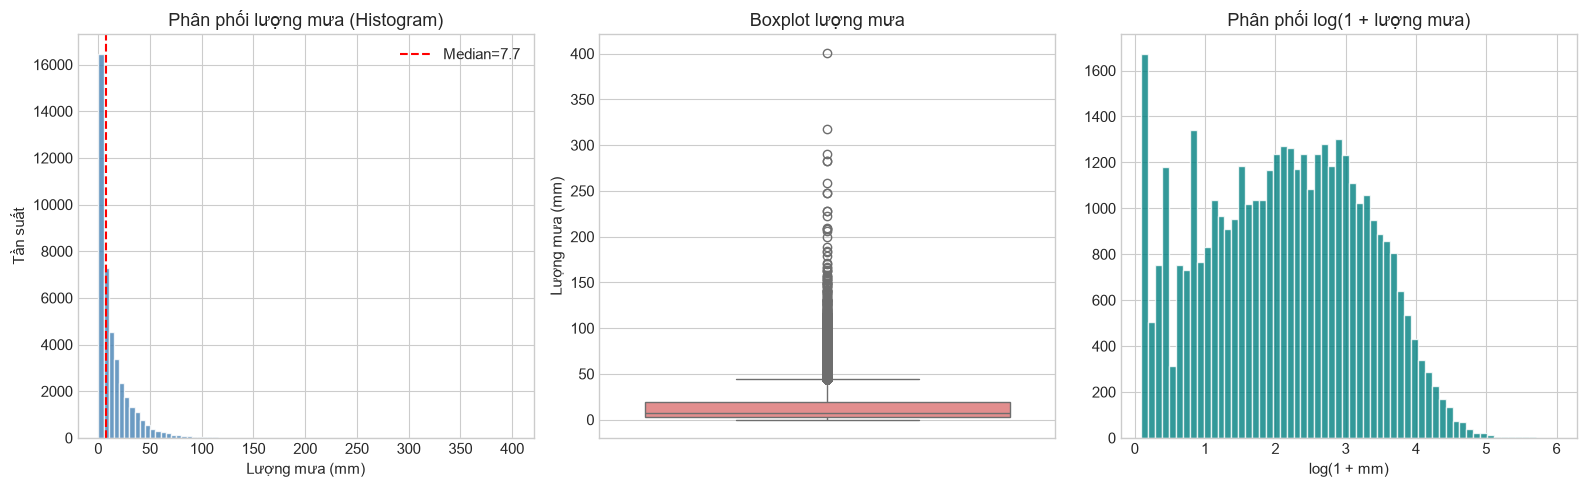


Thống kê mô tả lượng mưa (df_daily):
count   41368.00
mean       14.03
std        17.87
min         0.10
25%         2.40
50%         7.70
75%        19.00
90%        35.50
95%        47.70
99%        81.20
max       401.00
Name: luongMua, dtype: float64


In [22]:
# 3.1 Phân phối lượng mưa (df_daily)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df_daily['luongMua'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Phân phối lượng mưa (Histogram)')
axes[0].set_xlabel('Lượng mưa (mm)')
axes[0].set_ylabel('Tần suất')
axes[0].axvline(df_daily['luongMua'].median(), color='red', linestyle='--',
                label=f'Median={df_daily["luongMua"].median():.1f}')
axes[0].legend()

sns.boxplot(y=df_daily['luongMua'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot lượng mưa')
axes[1].set_ylabel('Lượng mưa (mm)')

axes[2].hist(np.log1p(df_daily['luongMua']), bins=60, color='teal', edgecolor='white', alpha=0.8)
axes[2].set_title('Phân phối log(1 + lượng mưa)')
axes[2].set_xlabel('log(1 + mm)')

plt.tight_layout()
plt.show()

print('\nThống kê mô tả lượng mưa (df_daily):')
print(df_daily['luongMua'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

**Phân phối lượng mưa (Histogram - Dữ liệu gốc)**

* **Quan sát:** Phân phối lệch phải rất nặng (Right-skewed). Phần lớn tần suất tập trung ở dải lượng mưa nhỏ (dưới $20\text{ mm}$), trong đó cột cao nhất tiệm cận $16.000$ bản ghi ở mức xấp xỉ $0 - 5\text{ mm}$. Đường trung vị (Median) nằm ở mức $7.7\text{ mm}$.
* **Insight:** Mưa nhỏ và trung bình chiếm đa số trong các ngày có ghi nhận mưa. Do lệch phải nghiêm trọng, giá trị trung bình (Mean) sẽ bị kéo lên cao đáng kể so với Median và không đại diện tốt cho xu hướng trung tâm của dữ liệu.

**Boxplot lượng mưa (Phát hiện ngoại lệ)**

* **Quan sát:** Hộp IQR nằm rất thấp (dưới $20\text{ mm}$), trong khi xuất hiện một tập hợp dầy đặc các điểm ngoại lệ (Outliers) kéo dài từ trên $50\text{ mm}$ đến tận $400\text{ mm}$.
* **Insight:** Các hiện tượng mưa cực đoan (mưa rất to, trận bão lớn) xảy ra với tần suất không hiếm nhưng giá trị biến động cực kỳ rộng. Khi làm mô hình dự báo hoặc thống kê, cần xử lý cẩn thận các ngoại lệ này để tránh làm méo lệch kết quả dự báo.

**Phân phối log(1 + lượng mưa) (Sau biến đổi Log)**

* **Quan sát:** Sau khi áp dụng biến đổi $\log(1 + x)$, phân phối đã được kéo về dạng gần chuẩn (Symmetric / Bell-shaped curve) với đỉnh nằm trong khoảng $\log(1 + \text{mm})$ từ $2$ đến $3$ (tương đương lượng mưa thực tế khoảng $6.4 - 19.1\text{ mm}$). Có một số cột nhọn ở dải giá trị nhỏ biểu diễn các mức mưa định lượng cố định.
* **Insight:** Biến đổi Log giúp giảm thiểu tác động của ngoại lệ và hiện tượng lệch phải, làm cho dữ liệu đáp ứng tốt hơn các giả định của các thuật toán Machine Learning (như Linear Regression, Neural Networks) hoặc các phép kiểm định thống kê parametric.

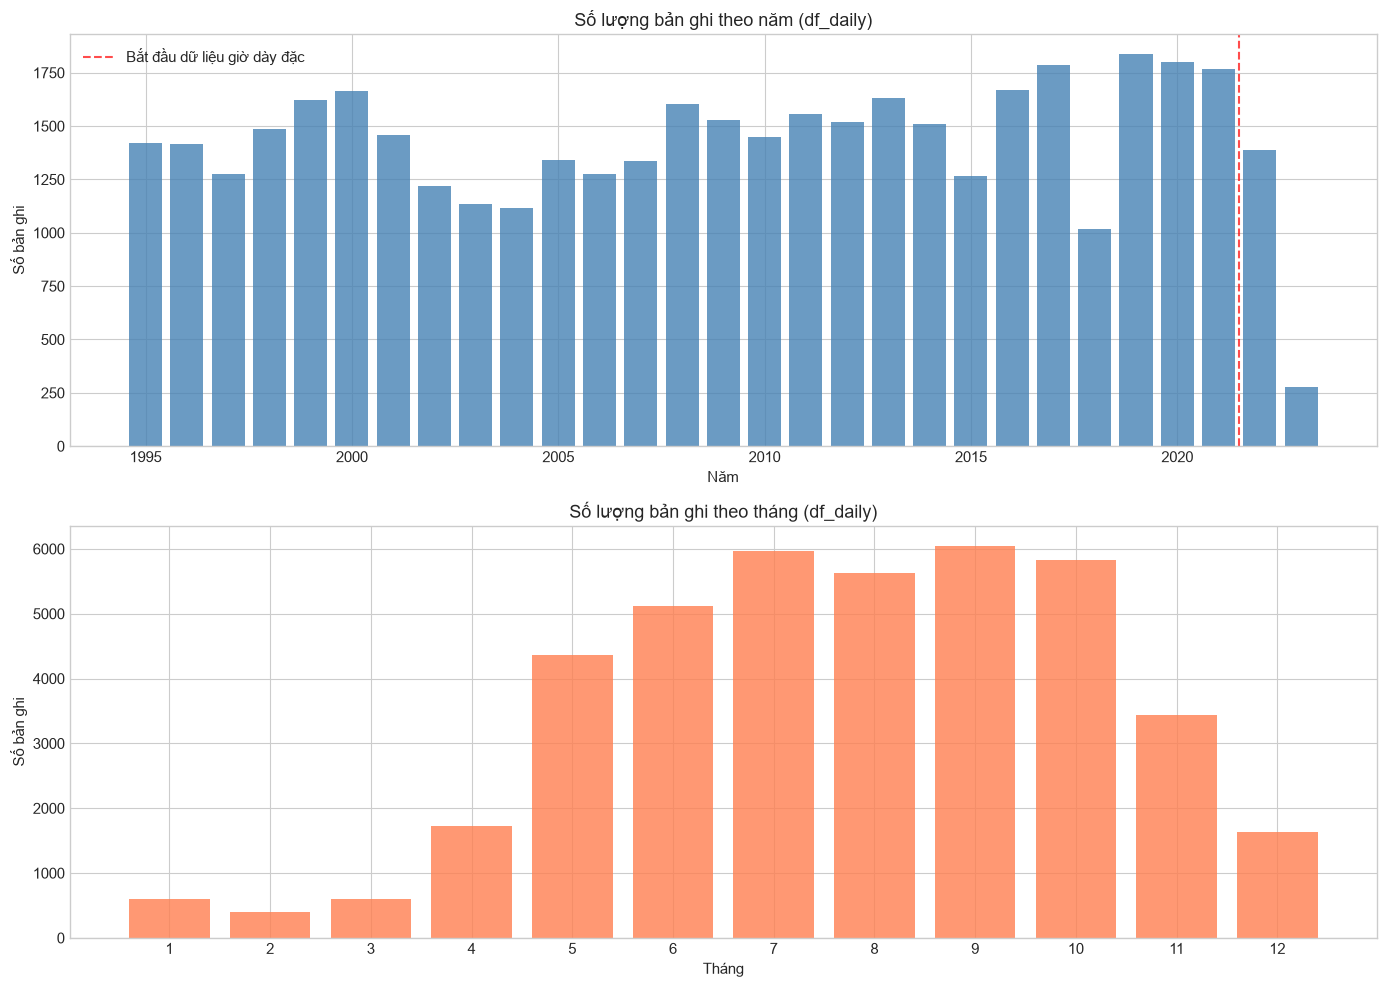

In [23]:
# 3.2 Phân bố theo năm & tháng (df_daily)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

year_counts = df_daily['year'].value_counts().sort_index()
axes[0].bar(year_counts.index, year_counts.values, color='steelblue', alpha=0.8)
axes[0].set_title('Số lượng bản ghi theo năm (df_daily)')
axes[0].set_xlabel('Năm')
axes[0].set_ylabel('Số bản ghi')
axes[0].axvline(2021.5, color='red', linestyle='--', alpha=0.7, label='Bắt đầu dữ liệu giờ dày đặc')
axes[0].legend()

month_counts = df_daily['month'].value_counts().sort_index()
axes[1].bar(month_counts.index, month_counts.values, color='coral', alpha=0.8)
axes[1].set_title('Số lượng bản ghi theo tháng (df_daily)')
axes[1].set_xlabel('Tháng')
axes[1].set_ylabel('Số bản ghi')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

#### Phân bố số lượng bản ghi theo thời gian

**Quan sát**

* **Theo Năm:**
* Số lượng bản ghi duy trì ổn định trong khoảng $1.100 - 1.800$ bản ghi/năm giai đoạn 1995–2021, đạt đỉnh cao nhất vào năm 2017 và 2019 (khoảng $1.800$ bản ghi), riêng năm 2018 sụt giảm bất thường xuống xấp xỉ $1.000$ bản ghi.
* Sau mốc bắt đầu xuất hiện dữ liệu đo theo giờ dày đặc (cuối năm 2021), số lượng bản ghi mức daily giảm dần ở năm 2022 và sụt giảm mạnh vào năm 2023 (chỉ còn dưới $300$ bản ghi).


* **Theo Tháng:**
* Các tháng mùa khô (tháng 1 đến tháng 3) có số lượng bản ghi rất thấp, rơi vào khoảng dưới $600$ bản ghi/tháng.
* Tần suất ghi nhận tăng mạnh từ tháng 4, duy trì mức rất cao trong suốt mùa mưa từ tháng 6 đến tháng 10 ($5.000 - 6.000$ bản ghi/tháng, cao nhất vào tháng 9) và giảm dần ở tháng 11, tháng 12.



**Insight**

* **Tác động của việc chuyển đổi định dạng dữ liệu (2022–2023):** Sự sụt giảm số lượng bản ghi daily từ cuối năm 2021 đến 2023 phản ánh sự chuyển đổi sang phương thức đo đạc theo giờ hoặc `tập dữ liệu năm 2023 chưa trích xuất trọn vẹn`. Cần lưu ý các giai đoạn biến động này (cùng với năm 2018) để tránh làm sai lệch xu hướng khi phân tích chuỗi thời gian dài hạn.
* **Tần suất mưa theo mùa:** Do dataset chỉ lưu các thời điểm thực sự phát sinh mưa, số lượng bản ghi phản ánh trực tiếp **tần suất xuất hiện ngày mưa/số trận mưa** trong năm. Dữ liệu thể hiện đúng quy luật khí hậu nhiệt đới gió mùa với mùa mưa kéo dài từ tháng 5 đến tháng 11, đỉnh điểm là tháng 9.

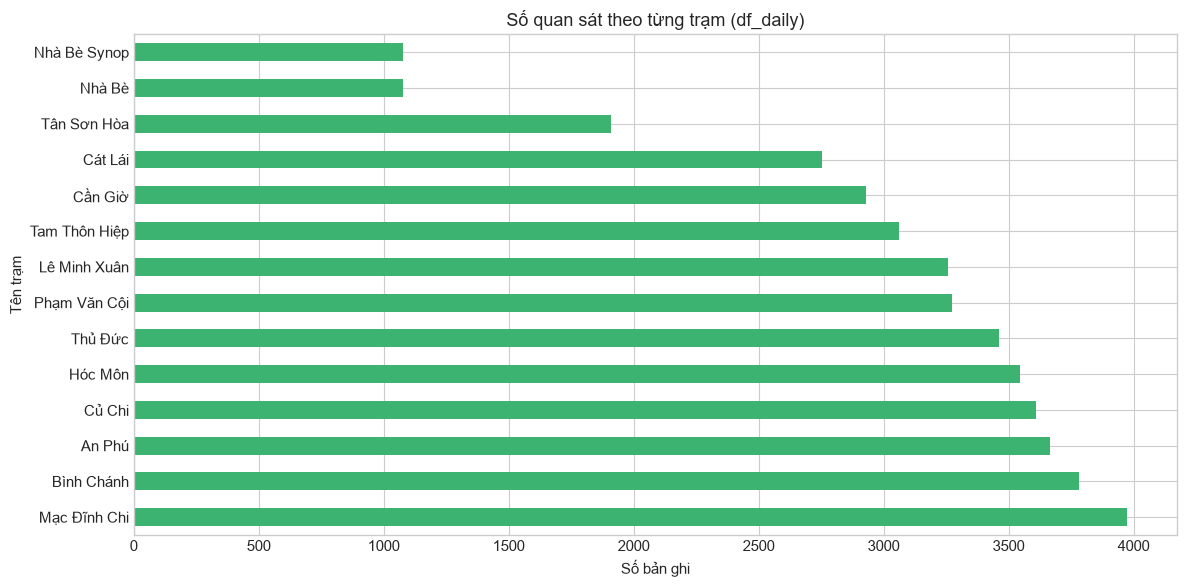

In [24]:
# 3.3 Phân bố theo trạm (df_daily)
station_counts = df_daily['tenTram'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
station_counts.plot(kind='barh', ax=ax, color='mediumseagreen')
ax.set_title('Số quan sát theo từng trạm (df_daily)')
ax.set_xlabel('Số bản ghi')
ax.set_ylabel('Tên trạm')
plt.tight_layout()
plt.show()

#### Phân bố số lượng quan sát theo từng trạm

**Quan sát**

* **Nhóm trạm có lượng dữ liệu nhiều nhất:**
* Trạm **Mạc Đĩnh Chi** đứng đầu với số lượng quan sát cao nhất, gần chạm mốc $4.000$ bản ghi.
* Nhóm các trạm ngoại thành và khu vực phụ cận như **Bình Chánh**, **An Phú**, **Củ Chi**, **Hóc Môn** cũng ghi nhận mật độ dữ liệu rất cao, dao động ổn định trong khoảng $3.500 - 3.800$ bản ghi.


* **Nhóm trạm có lượng dữ liệu ít nhất:**
* Hai trạm **Nhà Bè** và **Nhà Bè Synop** có số lượng quan sát thấp nhất trong toàn bộ hệ thống, chỉ đạt xấp xỉ $1.000 - 1.100$ bản ghi.
* Trạm **Tân Sơn Hòa** đứng ở vị trí tiếp theo từ dưới lên với khoảng $1.900$ bản ghi, chênh lệch đáng kể so với trạm dẫn đầu (chưa bằng $1/2$ lượng dữ liệu trạm Mạc Đĩnh Chi).



**Insight**

* **Mất cân bằng dữ liệu giữa các trạm (Data Imbalance):** Mật độ ghi nhận dữ liệu không đồng đều giữa các trạm thu thập. Sự chênh lệch lớn (từ $1.000$ đến gần $4.000$ bản ghi) có thể do các trạm được đưa vào vận hành ở các thời điểm lịch sử khác nhau, bị gián đoạn thiết bị đo, hoặc do tính chất quản lý dữ liệu giữa các nguồn (ĐKTTV vs CCTL) chưa đồng bộ.
* **Tác động đến bài toán phân tích không gian:** Khi thực hiện mô hình hóa spatial-temporal (không gian - thời gian) hoặc nội suy lượng mưa toàn khu vực, cần lưu ý trọng số của các trạm có chuỗi dữ liệu ngắn hơn (như Nhà Bè hay Tân Sơn Hòa) để tránh hiện tượng mô hình bị lệch (bias) về phía các trạm có mật độ quan sát dày đặc.

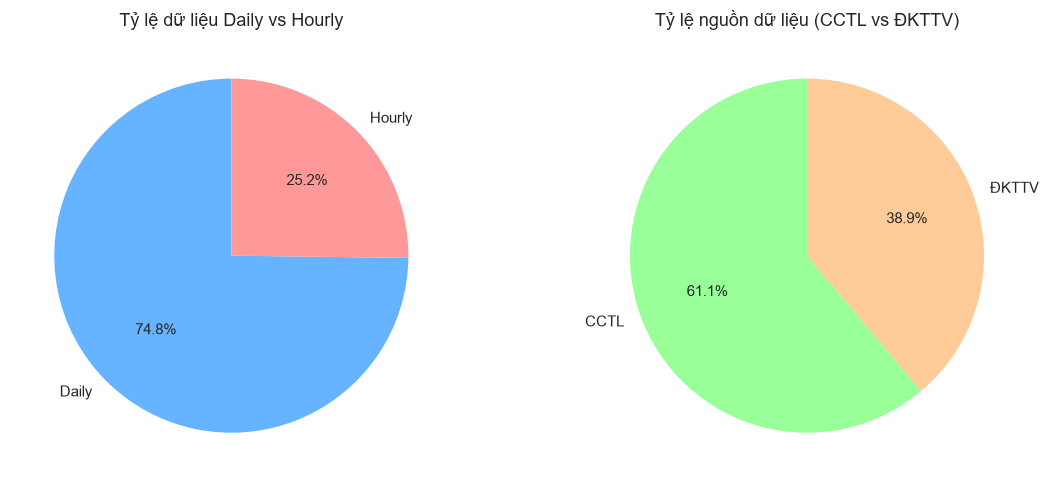

df_daily  : 41,368 dòng
df_hourly : 13,938 dòng


In [25]:
# 3.4 Tỷ lệ dữ liệu Daily vs Hourly + nguồn
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# So sánh số dòng 2 df
sizes = [len(df_daily), len(df_hourly)]
axes[0].pie(sizes, autopct='%1.1f%%', labels=['Daily', 'Hourly'],
            colors=['#66b3ff', '#ff9999'], startangle=90)
axes[0].set_title('Tỷ lệ dữ liệu Daily vs Hourly')

# Nguồn: gộp cả 2 df để xem tổng thể
df_all_source = pd.concat([
    df_daily[['source']],
    df_hourly[['source']]
], ignore_index=True)
df_all_source['source'].value_counts().plot.pie(
    ax=axes[1], autopct='%1.1f%%', colors=['#99ff99', '#ffcc99'], startangle=90
)
axes[1].set_title('Tỷ lệ nguồn dữ liệu (CCTL vs ĐKTTV)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f'df_daily  : {len(df_daily):,} dòng')
print(f'df_hourly : {len(df_hourly):,} dòng')

#### Phân bố tỷ lệ cấu trúc và nguồn dữ liệu

**Quan sát**

* **Tỷ lệ dữ liệu Daily vs Hourly:**
* Dữ liệu ghi nhận theo ngày (**Daily**) chiếm tỷ trọng áp đảo với $74.8\%$ tổng số bản ghi.
* Dữ liệu ghi nhận theo giờ (**Hourly**) chiếm khoảng khoảng $1/4$ còn lại, tương ứng $25.2\%$.


* **Tỷ lệ nguồn dữ liệu (CCTL vs ĐKTTV):**
* Nguồn dữ liệu từ Chi cục Thủy lợi (**CCTL**) chiếm đa số với tỷ lệ $61.1\%$.
* Nguồn dữ liệu từ Đài Khí tượng Thủy văn (**ĐKTTV**) đóng góp $38.9\%$ tổng số lượng quan sát.



**Insight**

* **Đặc tính phân rã độ phân giải thời gian:** Phần lớn lịch sử đo đạc trong quá khứ được lưu trữ ở dạng tổng kết theo ngày (Daily). Sự xuất hiện của $25.2\%$ dữ liệu Hourly cho thấy xu hướng nâng cấp hệ thống quan trắc sang mật độ dày hơn ở các năm gần đây, phục vụ cho việc phân tích các trận mưa rào/mưa cực đoan trong thời gian ngắn.
* **Sự kết hợp đa nguồn dữ liệu (Heterogeneous Sources):** Dataset được tổng hợp từ hai nguồn quản lý khác nhau với CCTL là nguồn thu thập chính. Do quy trình và tiêu chuẩn đo đạc giữa CCTL và ĐKTTV có thể có sự khác biệt, việc kiểm tra tính nhất quán (consistency check) và phân nhóm dữ liệu theo nguồn (`source`) là cần thiết khi thực hiện các phân tích chuyên sâu.

---
## 4. Bivariate & Multivariate Analysis

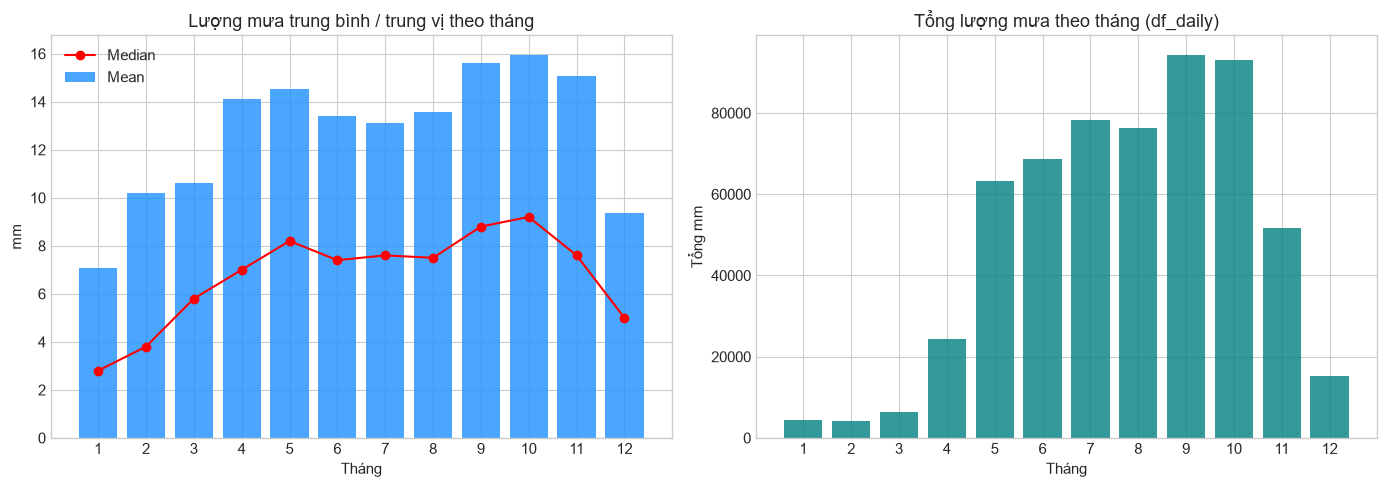

,mean,median,sum,count
month,,,,
1,7.08,2.80,4296.90,607
2,10.20,3.80,4152.30,407
3,10.60,5.80,6338.20,598
4,14.10,7.00,24385.30,1730
5,14.54,8.20,63348.20,4356
6,13.42,7.40,68749.30,5123
7,13.11,7.60,78306.50,5973
8,13.56,7.50,76227.70,5621
9,15.61,8.80,94395.00,6049


In [26]:
# 4.1 Lượng mưa trung bình theo tháng (df_daily)
monthly_rain = df_daily.groupby('month')['luongMua'].agg(['mean', 'median', 'sum', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(monthly_rain.index, monthly_rain['mean'], color='dodgerblue', alpha=0.8, label='Mean')
axes[0].plot(monthly_rain.index, monthly_rain['median'], color='red', marker='o', label='Median')
axes[0].set_title('Lượng mưa trung bình / trung vị theo tháng')
axes[0].set_xlabel('Tháng')
axes[0].set_ylabel('mm')
axes[0].set_xticks(range(1, 13))
axes[0].legend()

axes[1].bar(monthly_rain.index, monthly_rain['sum'], color='teal', alpha=0.8)
axes[1].set_title('Tổng lượng mưa theo tháng (df_daily)')
axes[1].set_xlabel('Tháng')
axes[1].set_ylabel('Tổng mm')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

display(monthly_rain.round(2))

#### Phân bố lượng mưa theo tháng

**Quan sát**

* **Lượng mưa trung bình (Mean) và Trung vị (Median):**
  - Lượng mưa trung bình hàng tháng luôn cao hơn giá trị trung vị ở mọi tháng, do tác động của các trận mưa cực đoan kéo lệch phân phối.
  - Cả Mean và Median đều đạt đỉnh cao nhất vào **Tháng 9** ($15.61\text{ mm}$ mean / $8.80\text{ mm}$ median) và **Tháng 10** ($15.96\text{ mm}$ mean / $9.20\text{ mm}$ median).
  - Mức mưa trung bình và trung vị thấp nhất rơi vào giai đoạn tháng 1 đến tháng 3 (thấp nhất là Tháng 1 với $7.08\text{ mm}$ mean / $2.80\text{ mm}$ median).


* **Tổng lượng mưa (Sum) và Số quan sát (Count):**
  - Tổng lượng mưa tích lũy tích tụ mạnh nhất ở hai tháng đỉnh điểm là **Tháng 9** ($94.395\text{ mm}$) và **Tháng 10** ($93.086.5\text{ mm}$), tương ứng với tần suất ghi nhận mưa dày đặc nhất (trên $5.800 - 6.000$ bản ghi/tháng).
  - Giai đoạn mùa khô (Tháng 1 – Tháng 3) ghi nhận tổng lượng mưa rất khiêm tốn, chỉ chiếm một phần rất nhỏ (dao động từ $4.100 - 6.300\text{ mm}$/tháng với $400 - 600$ bản ghi).
  - Tháng 4 và Tháng 12 đóng vai trò là các tháng chuyển tiếp mùa với lượng mưa tăng/giảm rõ rệt.



**Insight**

* **Tính phân hóa mùa cực kỳ rõ nét:** Mùa mưa kéo dài từ tháng 5 đến tháng 11, chiếm đại đa số tổng lượng mưa trong năm. Trong đó, tháng 9 và tháng 10 không chỉ là hai tháng có **mật độ xuất hiện các trận mưa nhiều nhất** mà còn là thời điểm có **cường độ mưa đỉnh điểm** (Mean và Median đều đạt giá trị tối đa).
* **Độ lệch phân phối bền vững theo thời gian:** Việc đường Trung vị (Median) luôn nằm thấp hơn đáng kể so với cột Trung bình (Mean) ở cả 12 tháng chứng minh hiện tượng **mưa cực đoan (outliers)** xuất hiện rải rác quanh năm, không chỉ riêng trong mùa mưa. Do đó, khi đánh giá lượng mưa kỳ vọng theo tháng, giá trị Median sẽ phản ánh chính xác hơn mức độ mưa thực tế của một ngày trung bình.

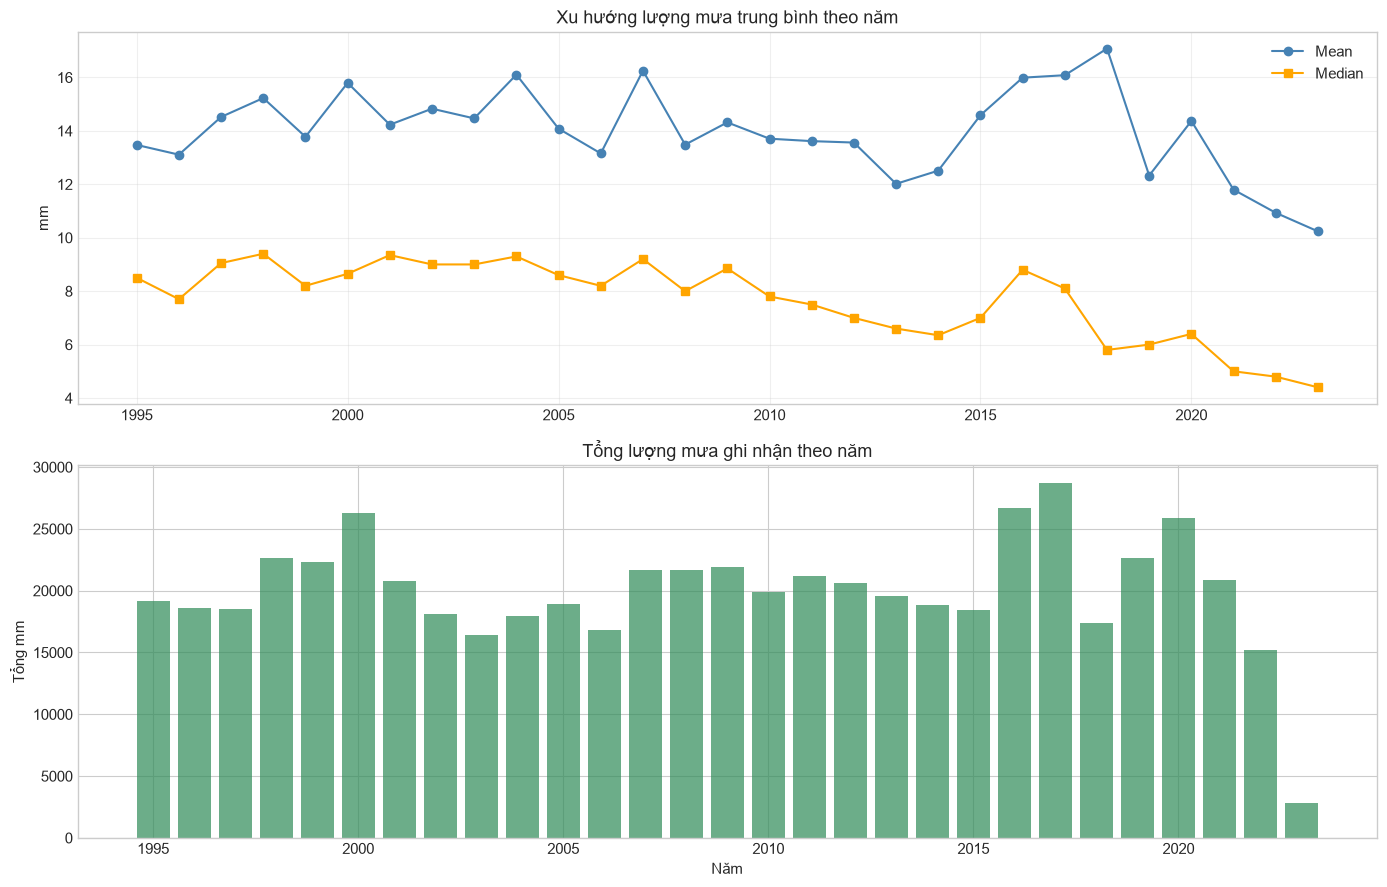

In [27]:
# 4.2 Lượng mưa trung bình theo năm (df_daily)
yearly_rain = df_daily.groupby('year')['luongMua'].agg(['mean', 'median', 'sum', 'count', 'max'])

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(yearly_rain.index, yearly_rain['mean'], marker='o', color='steelblue', label='Mean')
axes[0].plot(yearly_rain.index, yearly_rain['median'], marker='s', color='orange', label='Median')
axes[0].set_title('Xu hướng lượng mưa trung bình theo năm')
axes[0].set_ylabel('mm')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(yearly_rain.index, yearly_rain['sum'], color='seagreen', alpha=0.7)
axes[1].set_title('Tổng lượng mưa ghi nhận theo năm')
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('Tổng mm')

plt.tight_layout()
plt.show()

#### Xu hướng lượng mưa theo năm

**Quan sát**

* **Xu hướng lượng mưa trung bình (Mean) và Trung vị (Median):**
  - Trong giai đoạn 1995–2007, Mean dao động quanh dải $13 - 16\text{ mm}$ và Median ổn định ở mức $8 - 9.5\text{ mm}$.
  - Từ sau năm 2007, cả Mean và Median có xu hướng giảm dần, chạm đáy ngắn hạn vào khoảng 2013–2014 ($6.4\text{ mm}$ median).
  - Giai đoạn 2015–2018 ghi nhận sự phục hồi mạnh mẽ: Mean đạt đỉnh lịch sử vượt mốc $17\text{ mm}$ (năm 2018) và Median đạt khoảng $8.8\text{ mm}$ (năm 2016).
  - Từ năm 2019 đến 2023, cả đường Mean và Median đều giảm sâu liên tục, chạm mức thấp nhất lịch sử vào năm 2023 (Mean khoảng $10.2\text{ mm}$, Median tụt xuống dưới $4.5\text{ mm}$).


* **Tổng lượng mưa ghi nhận theo năm (Sum):**
  - Tổng lượng mưa tích lũy hàng năm biến động chu kỳ rõ rệt, dao động phổ biến từ $16.000 - 23.000\text{ mm}$ ở đa số các năm.
  - Các năm đạt tổng lượng mưa cao kỷ lục bao gồm **2000** ($>26.000\text{ mm}$), **2016–2017** (đạt đỉnh gần $29.000\text{ mm}$), và **2020** (khoảng $26.000\text{ mm}$).
  - Năm **2018** có tổng lượng mưa sụt giảm đáng kể (xuống khoảng $17.000\text{ mm}$) dù Mean năm này đạt đỉnh.
  - Năm **2022** và **2023** ghi nhận tổng lượng mưa giảm mạnh, đặc biệt năm 2023 sụt giảm xuống dưới $3.000\text{ mm}$.



**Insight**

* **Bất thường giữa Mean và Tổng lượng mưa năm 2018:** Năm 2018 có Mean đạt đỉnh cao nhất toàn chuỗi nhưng Tổng lượng mưa lại giảm mạnh. Nguyên nhân xuất phát từ việc **số lượng bản ghi năm 2018 bị sụt giảm bất thường** (chỉ có ~1.000 bản ghi thay vì 1.500+ như các năm khác), dẫn đến việc ít trận mưa hơn nhưng các trận mưa được ghi nhận có cường độ rất lớn.
* **Sự lệch pha dữ liệu giai đoạn 2021–2023:** Xu hướng sụt giảm sút nghiêm trọng của cả Mean, Median và Tổng lượng mưa từ 2021 đến 2023 không phản ánh hiện tượng hạn hán thực tế, mà do **thay đổi trong quy trình thu thập/gộp dữ liệu theo giờ (Hourly)** và tập dữ liệu năm 2023 chưa được thu thập đầy đủ cả năm.
* **Biến đổi khí hậu & Chu kỳ lượng mưa:** Dữ liệu cho thấy tính dao động chu kỳ đa năm (multi-year variability) rõ rệt với các mốc cực đoan (như đỉnh mưa năm 2000, 2016–2017). Đường Mean luôn nằm cao hơn đáng kể so với Median qua tất cả các năm, khẳng định các hiện tượng mưa cực đoan (outliers) xảy ra đều đặn và đóng vai trò chủ chốt làm tăng tổng lượng mưa hàng năm.

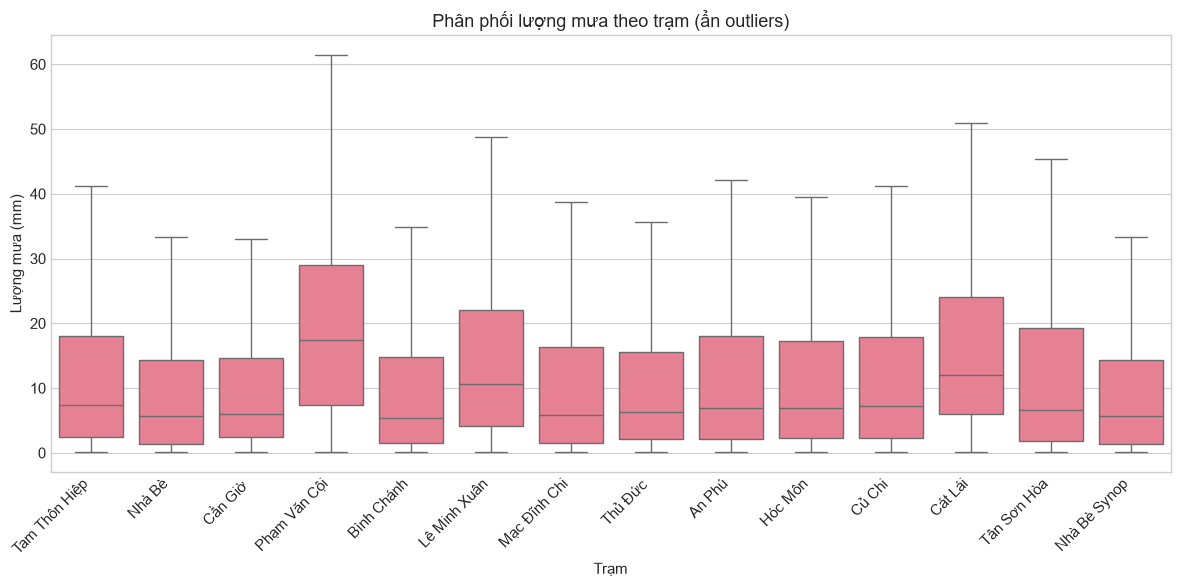

=== Thống kê theo trạm ===


,mean,median,std,max,count
tenTram,,,,,
Phạm Văn Cội,19.94,17.50,16.33,163.20,3272
Cát Lái,17.90,12.00,18.76,282.80,2752
Lê Minh Xuân,16.15,10.60,18.17,248.20,3256
Tân Sơn Hòa,14.58,6.60,21.38,401.00,1909
Tam Thôn Hiệp,13.86,7.40,17.65,317.80,3060
Củ Chi,13.72,7.20,18.17,258.80,3609
An Phú,13.71,7.00,17.89,155.90,3667
Hóc Môn,13.15,7.00,17.76,282.80,3545
Thủ Đức,12.52,6.30,17.61,208.60,3460


In [28]:
# 4.3 So sánh lượng mưa giữa các trạm (df_daily)
station_stats = (df_daily.groupby('tenTram')['luongMua']
                 .agg(['mean', 'median', 'std', 'max', 'count'])
                 .sort_values('mean', ascending=False))

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_daily, x='tenTram', y='luongMua', ax=ax, showfliers=False)
ax.set_title('Phân phối lượng mưa theo trạm (ẩn outliers)')
ax.set_xlabel('Trạm')
ax.set_ylabel('Lượng mưa (mm)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('=== Thống kê theo trạm ===')
display(station_stats.round(2))

#### Phân bố và cường độ lượng mưa theo từng trạm

**Quan sát**

* **Giá trị trung bình (Mean) và Trung vị (Median):**
  - **Phạm Văn Cội** là trạm có lượng mưa trung bình và trung vị vượt trội nhất toàn hệ thống (Mean $19.94\text{ mm}$, Median $17.50\text{ mm}$), vượt xa trạm xếp thứ hai là **Cát Lái** (Mean $17.90\text{ mm}$, Median $12.00\text{ mm}$).
  - Nhóm các trạm nội thành và phía Nam/Ven biển như **Nhà Bè / Nhà Bè Synop** (Mean $11.80\text{ mm}$, Median $5.70\text{ mm}$), **Cần Giờ** (Mean $11.75\text{ mm}$, Median $6.00\text{ mm}$), và **Bình Chánh** (Mean $11.55\text{ mm}$, Median $5.40\text{ mm}$) có lượng mưa trung bình và trung vị ở mức thấp nhất.


* **Biến động và Lượng mưa cực đại (Std & Max):**
  - **Tân Sơn Hòa** có độ lệch chuẩn cao nhất ($21.38\text{ mm}$) và ghi nhận giá trị lượng mưa ngày cực đại lịch sử cao nhất toàn hệ thống ($401.0\text{ mm}$), dù lượng mưa trung vị chỉ ở mức $6.60\text{ mm}$.
  - Trạm **Cát Lái**, **Tam Thôn Hiệp**, **Cần Giờ**, và **Hóc Môn** cũng ghi nhận các trận mưa cực đoan đạt mốc $280 - 318\text{ mm}$.
  - Hai trạm **Nhà Bè** và **Nhà Bè Synop** trùng khớp hoàn toàn $100\%$ về toàn bộ các chỉ số thống kê (Mean, Median, Std, Max, Count).



**Insight**

* **Sự phân hóa địa lý về cường độ mưa:** Dữ liệu cho thấy xu hướng phân hóa rõ rệt từ Bắc/Tây Bắc xuống Nam/Đông Nam. Trạm phía Bắc (**Phạm Văn Cội - Củ Chi**) có lượng mưa nền trung bình cao nhất, trong khi khu vực phía Nam/Ven biển (**Nhà Bè, Cần Giờ, Bình Chánh**) có lượng mưa ngày phổ biến tương đối thấp.
* **Nguy cơ ngập lụt cục bộ tại Tân Sơn Hòa & Cát Lái:** Dù lượng mưa trung vị ngày khá khiêm tốn ($6.60\text{ mm}$), trạm Tân Sơn Hòa lại sở hữu biên độ dao động rộng và kỷ lục mưa cực đoan lên tới $401\text{ mm}$. Điều này phản ánh các đợt mưa rào cực đoan trong thời gian ngắn, nguy cơ cao gây ngập lụt nghiêm trọng cho khu vực trung tâm/sân bay.
* **Dữ liệu trùng lặp (Duplicate Data):** Việc trạm **Nhà Bè** và **Nhà Bè Synop** có tất cả các chỉ số giống hệt nhau ($1.077$ bản ghi, Mean $11.80$, Max $227.60$) khẳng định đây là 2 tên gọi đại diện cho cùng một trạm đo từ hai nguồn ghi nhận khác nhau. Cần tiến hành gộp/loại bỏ dữ liệu trùng lặp trước khi mô hình hóa.

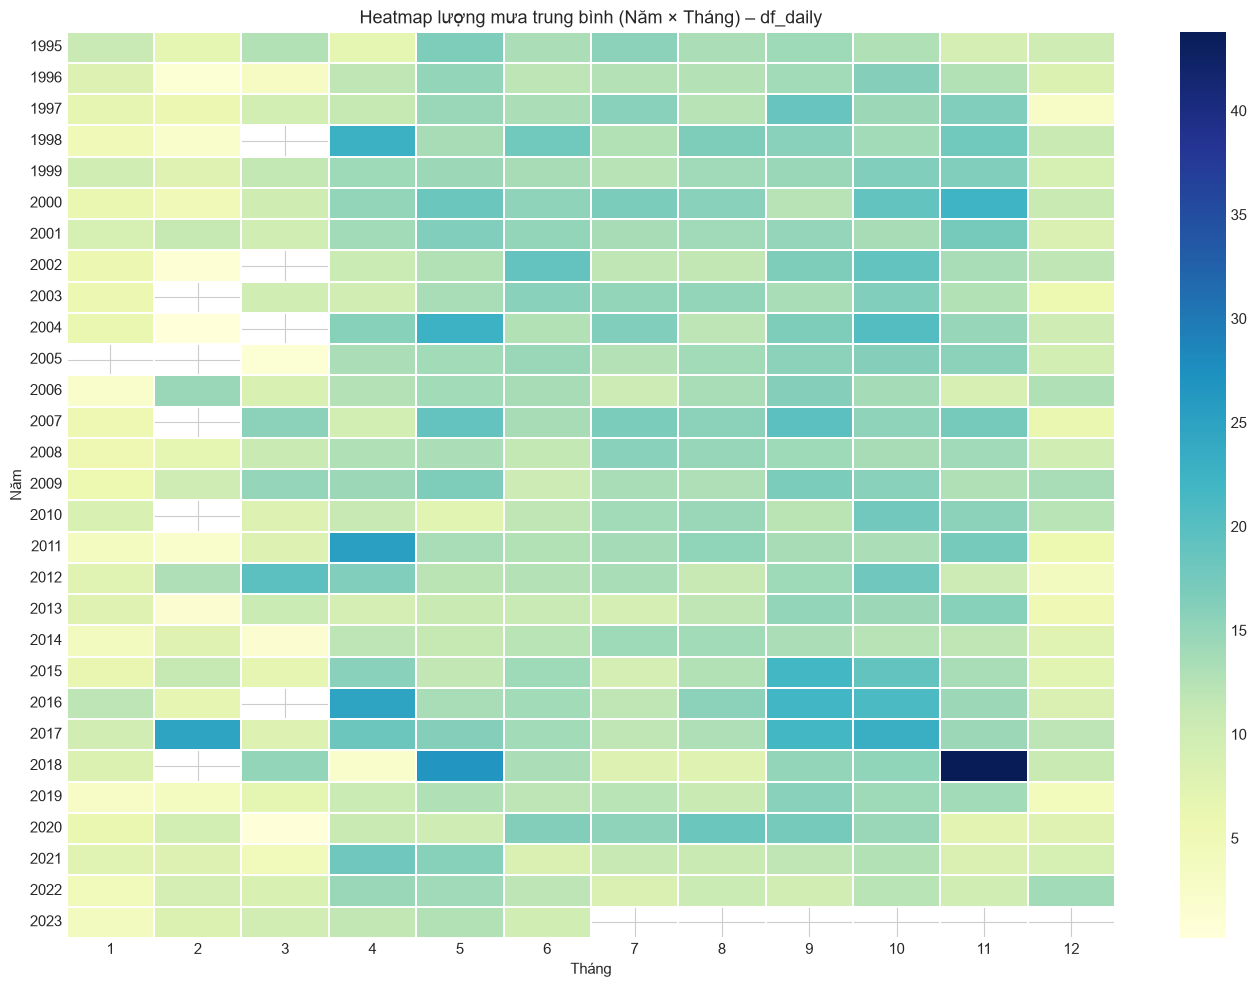

In [29]:
# 4.4 Heatmap lượng mưa trung bình theo năm × tháng (df_daily)
pivot = df_daily.pivot_table(values='luongMua', index='year', columns='month', aggfunc='mean')

plt.figure(figsize=(14, 10))
sns.heatmap(pivot, cmap='YlGnBu', annot=False, linewidths=0.3)
plt.title('Heatmap lượng mưa trung bình (Năm × Tháng) – df_daily')
plt.xlabel('Tháng')
plt.ylabel('Năm')
plt.tight_layout()
plt.show()

#### Biến động lượng mưa trung bình theo Năm và Tháng (Heatmap)

**Quan sát**

* **Tính phân hóa theo tháng (Mùa mưa & Mùa khô):**
  - Các ô màu vàng nhạt (giá trị $< 10\text{ mm}$) tập trung chủ yếu ở giai đoạn tháng 1 đến tháng 3 và tháng 12 hàng năm, thể hiện rõ đặc đặc trưng của mùa khô.
  - Các ô màu xanh lục và xanh lam ($15 - 30\text{ mm}$) trải dài liên tục từ tháng 5 đến tháng 11 across các năm, ghi nhận mùa mưa diễn ra bền vững.


* **Các giá trị dị thường (Outliers/Anomaly):**
  - **Tháng 11/2018** xuất hiện ô màu xanh đậm nhất toàn bảng ($> 40\text{ mm}$), là mức trung bình tháng cao kỷ lục trong toàn bộ chuỗi lịch sử 1995–2023.
  - Các đợt mưa trái mùa cực đoan xuất hiện rải rác như **Tháng 4/2011**, **Tháng 3/2012**, hay **Tháng 2/2017** với các ô xanh lam nõn ($20 - 25\text{ mm}$).


* **Dữ liệu khuyết thiếu (Missing values):**
  - Các ô trắng xuất hiện rải rác ở những tháng mùa khô của một số năm (như 1998, 2002, 2004, 2005, 2007, 2010, 2016, 2018).
  - Năm **2023** hoàn toàn thiếu dữ liệu từ tháng 7 đến tháng 12.



**Insight**

* **Tính bất thường của trận siêu bão/mưa lớn cuối năm 2018:** Cụm màu xanh đậm khác biệt ở tháng 11/2018 là do ảnh hưởng của cơn bão Usagi (bão số 9 năm 2018) gây ra trận mưa lịch sử trên toàn TP.HCM, làm lượng mưa trung bình tháng bị đẩy lên mức cực đại.
* **Xu hướng mưa trái mùa tăng tần suất:** Các ô màu đậm bất thường ở giai đoạn tháng 2–tháng 4 (mùa khô) xuất hiện dày hơn ở nửa sau chuỗi thời gian (từ 2011 trở đi), cho thấy dấu hiệu của biến đổi khí hậu khiến quy luật phân bố mưa theo mùa bớt tính ổn định.
* **Giới hạn chuỗi dữ liệu (Data Coverage Limit):** Tập dữ liệu 2023 chỉ mới ghi nhận đến hết tháng 6. Cần thực hiện xử lý khuyết thiếu (imputation) hoặc cắt gọt chuỗi phù hợp đối với các ô trống rải rác trước khi huấn luyện mô hình dự báo chuỗi thời gian (Time Series Forecasting).

---
## 5. Spatial Analysis – Phân tích không gian

In [30]:
# 5. Spatial – tọa độ & lượng mưa TB theo trạm (df_daily)
station_geo = df_daily.groupby('tenTram').agg({
    'kinhDo': 'mean',
    'viDo': 'mean',
    'luongMua': 'mean',
    'maHuyen': 'first',
    'FID': 'count'
}).rename(columns={'FID': 'n_records', 'luongMua': 'mean_rain'}).reset_index()

print('=== Vị trí các trạm ===')
display(station_geo.sort_values('mean_rain', ascending=False).round(4))

=== Vị trí các trạm ===


,tenTram,kinhDo,viDo,mean_rain,maHuyen,n_records
10,Phạm Văn Cội,106.52,11.04,19.94,783,3272
2,Cát Lái,106.77,10.77,17.90,769,2752
6,Lê Minh Xuân,106.54,10.78,16.15,785,3256
13,Tân Sơn Hòa,106.67,10.80,14.58,766,1909
11,Tam Thôn Hiệp,106.86,10.60,13.86,787,3060
4,Củ Chi,106.51,10.96,13.72,783,3609
0,An Phú,106.51,11.11,13.71,783,3667
5,Hóc Môn,106.60,10.89,13.15,784,3545
12,Thủ Đức,106.76,10.84,12.52,769,3460
7,Mạc Đĩnh Chi,106.70,10.78,12.52,760,3975


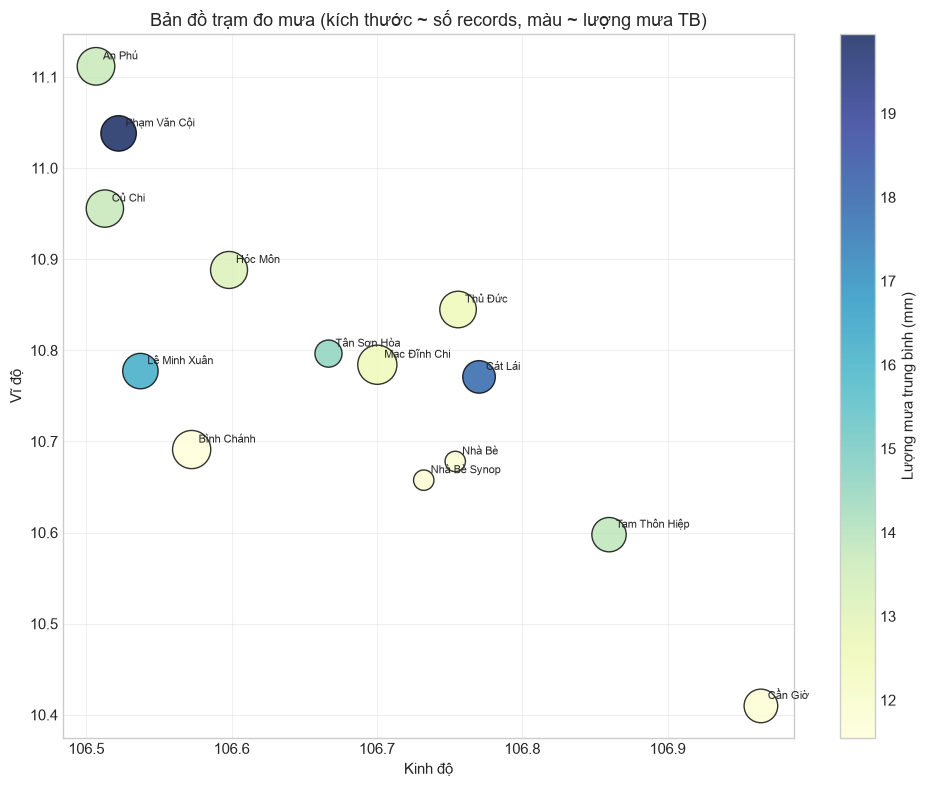

In [31]:
# Scatter map
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    station_geo['kinhDo'], station_geo['viDo'],
    s=station_geo['n_records'] / 5,
    c=station_geo['mean_rain'],
    cmap='YlGnBu', alpha=0.8, edgecolors='k'
)

for _, row in station_geo.iterrows():
    ax.annotate(row['tenTram'], (row['kinhDo'], row['viDo']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

plt.colorbar(scatter, label='Lượng mưa trung bình (mm)')
ax.set_xlabel('Kinh độ')
ax.set_ylabel('Vĩ độ')
ax.set_title('Bản đồ trạm đo mưa (kích thước ~ số records, màu ~ lượng mưa TB)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Phân bố không gian các trạm đo mưa

**Quan sát**

* **Phân bố địa lý và Mật độ dữ liệu (Kích thước bóng bóng):**
  - Các trạm trải dài theo hướng Tây Bắc – Đông Nam, bám sát địa giới hành chính của TP.HCM từ phía Bắc (**Phạm Văn Cội**, **An Phú**, **Củ Chi**) xuống phía Nam/Ven biển (**Tam Thôn Hiệp**, **Cần Giờ**).
  - Hầu hết các trạm ở khu vực phía Bắc và Tây Nam (**Bình Chánh**, **Củ Chi**, **An Phú**, **Hóc Môn**, **Mạc Đĩnh Chi**) có kích thước bóng bóng lớn, tương ứng với số lượng bản ghi (records) dày đặc.
  - Hai trạm **Nhà Bè** và **Nhà Bè Synop** nằm đè lên nhau tại cùng mốc tọa độ (Kinh độ $\approx 106.75$, Vĩ độ $\approx 106.66$) với kích thước bong bóng rất nhỏ (lượng records ít).


* **Phân hóa cường độ mưa trung bình (Màu sắc bóng bóng):**
  - Trạm **Phạm Văn Cội** nổi bật với màu xanh lam đậm nhất (lượng mưa trung bình tiệm cận mốc $20\text{ mm}$), nằm ở tọa độ cao nhất về phía Bắc (Vĩ độ $\approx 11.04$).
  - Trạm **Cát Lái** ở khu vực phía Đông và **Lê Minh Xuân** ở phía Tây sở hữu gam màu xanh lam nõn/xanh dương nhạt, tương ứng lượng mưa trung bình cao từ $16 - 18\text{ mm}$.
  - Cụm các trạm khu vực trung tâm và phía Nam/Đông Nam (**Mạc Đĩnh Chi**, **Thủ Đức**, **Bình Chánh**, **Nhà Bè**, **Cần Giờ**) đều phủ màu vàng nhạt đến xanh lá cây nhạt, tương ứng lượng mưa trung bình ở mức thấp ($11.5 - 13.5\text{ mm}$).



**Insight**

* **Gradient mưa từ Bắc xuống Nam:** Bản đồ thể hiện rõ nét quy luật phân bố không gian: lượng mưa trung bình có xu hướng giảm dần theo chiều từ Bắc/Tây Bắc xuống Nam/Đông Nam. Khu vực Củ Chi/Phạm Văn Cội nhận lượng mưa nền cao hơn hẳn so với vùng ven biển cằn cỗi/ngập mặn như Cần Giờ, Tam Thôn Hiệp.
* **Xác nhận tọa độ trùng khớp của trạm Nhà Bè:** Vị trí đè lấp hoàn toàn giữa **Nhà Bè** và **Nhà Bè Synop** trên bản đồ không gian khẳng định đây là cùng một trạm vật lý trên thực địa.
* **Định hướng nội suy không gian (Spatial Interpolation):** Phân bố trạm tương đối đều dọc theo chiều dốc địa hình TP.HCM, tuy nhiên mật độ trạm ở vùng lõi trung tâm hơi thưa. Khi xây dựng bản đồ phân bố mưa dạng bề mặt (Raster surface) bằng phương pháp IDW hay Kriging, trạm cực bắc Phạm Văn Cội và trạm phía Đông Cát Lái sẽ đóng vai trò các điểm khống chế trọng yếu quyết định biên độ mưa cực đại.

---
## 6. Time Series Analysis

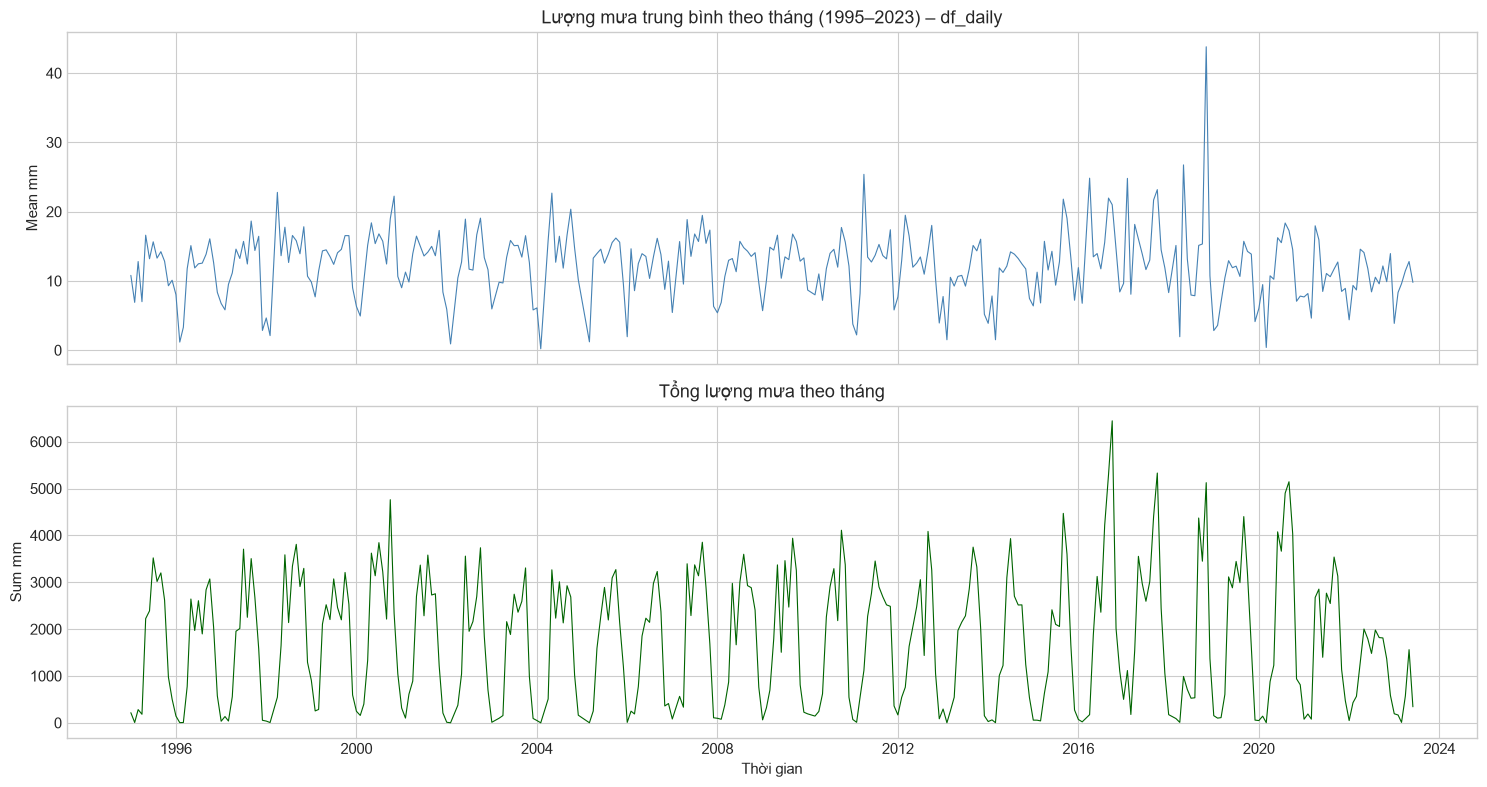

In [32]:
# 6.1 Chuỗi thời gian tổng hợp theo tháng (df_daily)
df_daily['year_month'] = df_daily['ngay'].dt.to_period('M')
ts_monthly = df_daily.groupby('year_month')['luongMua'].agg(['mean', 'sum', 'count']).reset_index()
ts_monthly['year_month'] = ts_monthly['year_month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(ts_monthly['year_month'], ts_monthly['mean'], color='steelblue', linewidth=0.8)
axes[0].set_title('Lượng mưa trung bình theo tháng (1995–2023) – df_daily')
axes[0].set_ylabel('Mean mm')

axes[1].plot(ts_monthly['year_month'], ts_monthly['sum'], color='darkgreen', linewidth=0.8)
axes[1].set_title('Tổng lượng mưa theo tháng')
axes[1].set_ylabel('Sum mm')
axes[1].set_xlabel('Thời gian')

plt.tight_layout()
plt.show()

#### Diễn biến chuỗi thời gian lượng mưa theo tháng (1995–2023)

**Quan sát**

* **Lượng mưa trung bình theo tháng (Mean mm):**
  - Đồ thị biến động liên tục dạng hình răng cưa theo chu kỳ hàng năm, trung bình phổ biến dao động trong khoảng $5 - 20\text{ mm}$.
  - Xuất hiện đỉnh nhọn bất thường vượt trội hoàn toàn vào **cuối năm 2018** với lượng mưa trung bình tháng đạt kỷ lục vượt mốc $40\text{ mm}$ (gấp đôi so với các đỉnh thông thường).
  - Biên độ dao động của các đỉnh tăng cao và có xu hướng "mất ổn định" hơn trong giai đoạn từ năm 2015 trở đi.


* **Tổng lượng mưa theo tháng (Sum mm):**
  - Thể hiện rõ nét tính mùa vụ (Seasonality) lặp lại đều đặn hàng năm: tổng lượng mưa chạm đáy tiệm cận $0\text{ mm}$ vào đầu mỗi năm (mùa khô) và tạo đỉnh vào giữa/cuối năm (mùa mưa).
  - Các đỉnh tổng lượng mưa thông thường đạt từ $3.000 - 4.000\text{ mm}$.
  - Giai đoạn 2016–2020 ghi nhận các đỉnh tổng lượng mưa cao đột biến, đỉnh điểm là năm **2016** đạt gần $6.500\text{ mm}$ và năm **2018** vượt mốc $5.000\text{ mm}$.
  - Giai đoạn 2021–2023 ghi nhận các đỉnh tổng lượng mưa sụt giảm đáng kể (chỉ còn dưới $2.000\text{ mm}$).



**Insight**

* **Tính dừng và mùa vụ của chuỗi thời gian (Stationarity & Seasonality):** Chuỗi tổng lượng mưa (`Sum mm`) sở hữu tính mùa vụ cực kỳ mạnh mẽ và tương đối ổn định về mặt chu kỳ (12 tháng). Tuy nhiên, chuỗi lượng mưa trung bình (`Mean mm`) lại ghi nhận những đợt bùng nổ biên độ ở nửa sau chuỗi lịch sử (sau 2015), phản ánh tần suất các hiện tượng thời tiết cực đoan/mưa dầm diện rộng gia tăng.
* **Xác nhận lại dị thường năm 2018:** Đỉnh nhọn đơn độc vượt $40\text{ mm}$ ở biểu đồ Mean vào cuối năm 2018 (do bão Usagi) không chỉ là ngoại lệ trên bảng Heatmap mà còn là điểm dị thường (outlier) lớn nhất toàn bộ chuỗi 28 năm history.
* **Ghi nhận sự suy giảm biên độ 2021–2023:** Sự sụt giảm của biểu đồ tổng lượng mưa ở giai đoạn cuối chuỗi thời gian tương thích hoàn toàn với các phân tích trước đó (do việc tập trung ghi nhận sang dữ liệu Hourly và tập dữ liệu 2023 chưa trọn vẹn). Khi huấn luyện các mô hình dự báo chuỗi thời gian (như ARIMA, Prophet, LSTM), cần thực hiện phân tách mùa vụ (Seasonal Decomposition) và xử lý cẩn thận đoạn dữ liệu suy giảm kỹ thuật này.

=== Thống kê theo thập niên ===


,mean,median,std,max,count
decade,,,,,
1990,14.02,8.60,15.75,133.50,7216
2000,14.65,8.70,16.92,227.60,13682
2010,14.04,7.10,19.50,401.00,15236
2020,12.37,5.40,17.94,189.20,5234


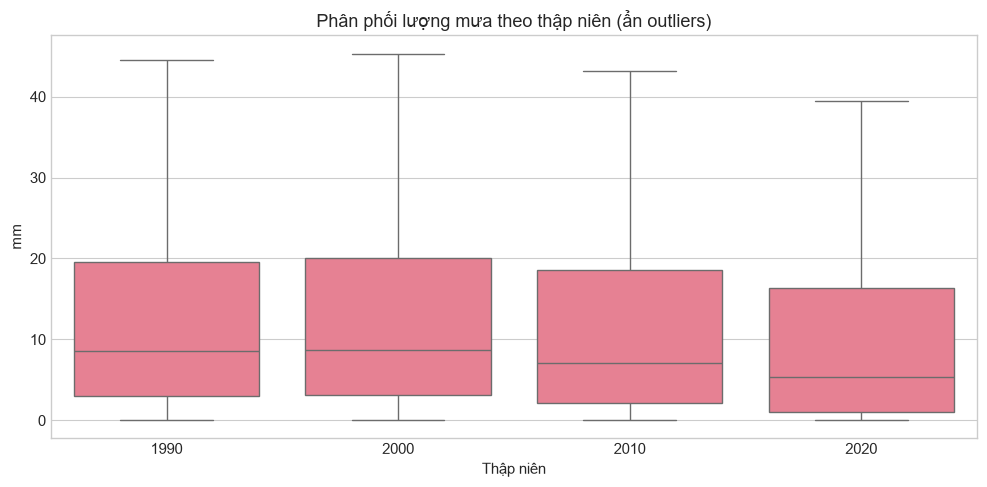

In [33]:
# 6.2 So sánh các thập niên (df_daily)
decade_stats = df_daily.groupby('decade')['luongMua'].agg(['mean', 'median', 'std', 'max', 'count'])
print('=== Thống kê theo thập niên ===')
display(decade_stats.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_daily, x='decade', y='luongMua', showfliers=False, ax=ax)
ax.set_title('Phân phối lượng mưa theo thập niên (ẩn outliers)')
ax.set_xlabel('Thập niên')
ax.set_ylabel('mm')
plt.tight_layout()
plt.show()

#### Phân bố lượng mưa theo thập niên

**Quan sát**

* **Thập niên 1990 và 2000:**
  - Phân phối khá tương đồng nhau với mức trung vị (Median) nằm ở mức cao nhất, khoảng $8.5\text{ mm}$.
  - Dải liên tứ phân vị (IQR - độ rộng của hộp) kéo dài từ $3\text{ mm}$ đến $20\text{ mm}$, ria trên (Whisker) mở rộng lên cận $45\text{ mm}$.


* **Thập niên 2010:**
  - Trung vị bắt đầu có sự sụt giảm nhẹ xuống mức xấp xỉ $7.0\text{ mm}$.
  - Cạnh trên của hộp (Q3) giảm nhẹ xuống dưới $19\text{ mm}$ và ria trên rút ngắn xuống còn khoảng $43\text{ mm}$.


* **Thập niên 2020:**
  - Mức trung vị chạm mốc thấp nhất trong các thập niên, rơi xuống khoảng $5.3\text{ mm}$.
  - Hộp IQR bị co hẹp lại (từ $1\text{ mm}$ đến khoảng $16.3\text{ mm}$) và ria trên sụt giảm hẳn xuống dưới mốc $40\text{ mm}$.



**Insight**

* **Xu hướng sụt giảm của các trận mưa quy mô trung bình:** Sự dịch chuyển xuống dưới của cả trung vị (Median) và phân vị thứ 75 (Q3) qua từng thập niên thể hiện lượng mưa tích lũy của một ngày mưa trung bình có xu hướng giảm dần từ giai đoạn 1990–2000 sang 2010–2020.
* **Tác động từ thay đổi cấu trúc dữ liệu thập niên 2020:** Việc thập niên 2020 có dải IQR và trung vị thấp vượt trội một phần lớn xuất phát từ **sự dịch chuyển độ phân giải dữ liệu (Hourly resampled)** ở giai đoạn 2021–2023 và tập dữ liệu chưa trọn vẹn của thập niên này.
* **Độ biến động giữa các giai đoạn:** Mặc dù lượng mưa nền giảm, khoảng cách ria trên ở cả 4 thập niên vẫn duy trì ở mức cao ($40 - 45\text{ mm}$), chứng tỏ nguy cơ xuất hiện các trận mưa lớn/mưa cực đoan vẫn diễn ra ổn định qua tất cả các thập kỷ chứ không bị mất đi.

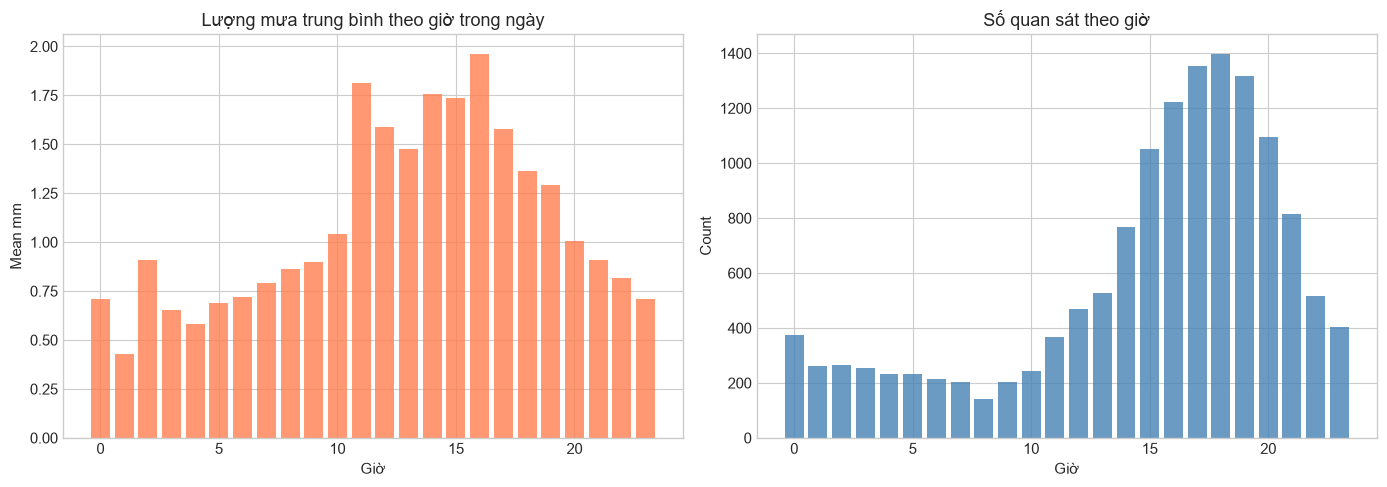

In [34]:
# 6.3 Phân tích theo giờ trong ngày (df_hourly)
if len(df_hourly) > 0 and 'gio' in df_hourly.columns:
    df_h = df_hourly.copy()
    df_h['hour'] = df_h['gio'].astype(str).str.split(':').str[0].astype(float)
    
    hour_stats = df_h.groupby('hour')['luongMua'].agg(['mean', 'count'])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].bar(hour_stats.index, hour_stats['mean'], color='coral', alpha=0.8)
    axes[0].set_title('Lượng mưa trung bình theo giờ trong ngày')
    axes[0].set_xlabel('Giờ')
    axes[0].set_ylabel('Mean mm')
    
    axes[1].bar(hour_stats.index, hour_stats['count'], color='steelblue', alpha=0.8)
    axes[1].set_title('Số quan sát theo giờ')
    axes[1].set_xlabel('Giờ')
    axes[1].set_ylabel('Count')
    
    plt.tight_layout()
    plt.show()
else:
    print('Không có dữ liệu hourly hoặc thiếu cột gio')

#### Phân bố lượng mưa và tần suất xuất hiện theo giờ trong ngày

**Quan sát**

* **Lượng mưa trung bình theo giờ (Mean mm):**
* Lượng mưa trung bình bắt đầu tăng vọt từ mốc $11$ giờ, duy trì mức rất cao suốt khung giờ chiều ($11 - 17$ giờ) và đạt đỉnh tối đa vào lúc **$16$ giờ** (tiệm cận mốc $2.0\text{ mm}$).
* Khung giờ đêm và sáng sớm ($1 - 9$ giờ) có lượng mưa trung bình tương đối thấp, phổ biến ở mức dưới $0.9\text{ mm}$ (thấp nhất vào khoảng $2 - 4$ giờ sáng).


* **Số quan sát theo giờ (Count):**
* Tần suất xuất hiện mưa có sự lệch pha nhẹ về phía chiều tối: số lượng bản ghi bắt đầu tăng tốc mạnh từ $12$ giờ, đạt đỉnh trong khoảng **$17 - 19$ giờ** (đỉnh điểm tại $18$ giờ với khoảng $1.400$ quan sát).
* Khung giờ từ $6 - 9$ giờ sáng ghi nhận ít trận mưa nhất trong ngày, chạm đáy vào lúc $8$ giờ với dưới $200$ quan sát.



**Insight**

* **Đặc trưng mưa đối lưu nhiệt đới (Diurnal Cycle):** Biểu đồ thể hiện quy luật mưa rào đối lưu điển hình của vùng khí hậu Nam Bộ. Vào ban ngày, bức xạ mặt trời làm nóng mặt đất, thúc đẩy dòng không khí bốc lên mạnh và tạo mây đối lưu, dẫn đến **mưa bắt đầu bùng nổ cường độ vào giữa trưa đến đầu giờ chiều ($11 - 16$ giờ)**.
* **Độ lệch giữa Cường độ và Tần suất mưa:**
* **Cường độ mưa đỉnh điểm** diễn ra sớm hơn (lúc $16$ giờ), đại diện cho các trận mưa rào trút xuống nhanh và mạnh.
* **Tần suất xuất hiện mưa đỉnh điểm** lại rơi vào kề sau đó ($17 - 19$ giờ), cho thấy các trận mưa chiều thường kéo dài rải rác hoặc chuyển sang dạng mưa dầm nhẹ hơn vào tầm giờ cao điểm chiều tối.


* **Định hướng ứng dụng thực tế:** Khung giờ từ $15 - 19$ giờ tập trung cả cường độ mưa lớn nhất lẫn tần suất mưa dày đặc nhất, trùng khớp với giờ tan tầm tại TP.HCM. Đây là thông tin quan trọng cho các mô hình cảnh báo ngập lụt đô thị và điều phối giao thông.

---
## 7. Outliers & Extreme Events

In [35]:
# 7.1 Xác định ngưỡng cực đoan (df_daily)
p95  = df_daily['luongMua'].quantile(0.95)
p99  = df_daily['luongMua'].quantile(0.99)
p999 = df_daily['luongMua'].quantile(0.999)

print(f'P95  = {p95:.1f} mm')
print(f'P99  = {p99:.1f} mm')
print(f'P99.9= {p999:.1f} mm')
print(f'Max  = {df_daily["luongMua"].max():.1f} mm')

top_events = df_daily.nlargest(20, 'luongMua')[['ngay', 'tenTram', 'luongMua', 'year', 'source']]
print('\n=== Top 20 trận mưa lớn nhất (df_daily) ===')
display(top_events)

P95  = 47.7 mm
P99  = 81.2 mm
P99.9= 146.0 mm
Max  = 401.0 mm

=== Top 20 trận mưa lớn nhất (df_daily) ===


,ngay,tenTram,luongMua,year,source
34146,2018-11-25,Tân Sơn Hòa,401.00,2018,ĐKTTV
34144,2018-11-25,Tam Thôn Hiệp,317.80,2018,CCTL
34137,2018-11-25,Cần Giờ,290.80,2018,CCTL
34136,2018-11-25,Cát Lái,282.80,2018,CCTL
34152,2018-11-26,Hóc Môn,282.80,2018,CCTL
34151,2018-11-26,Củ Chi,258.80,2018,CCTL
31619,2017-04-01,Lê Minh Xuân,248.20,2017,CCTL
34139,2018-11-25,Hóc Môn,247.40,2018,CCTL
8761,2000-11-25,Nhà Bè,227.60,2000,CCTL
34142,2018-11-25,Nhà Bè Synop,227.60,2018,CCTL


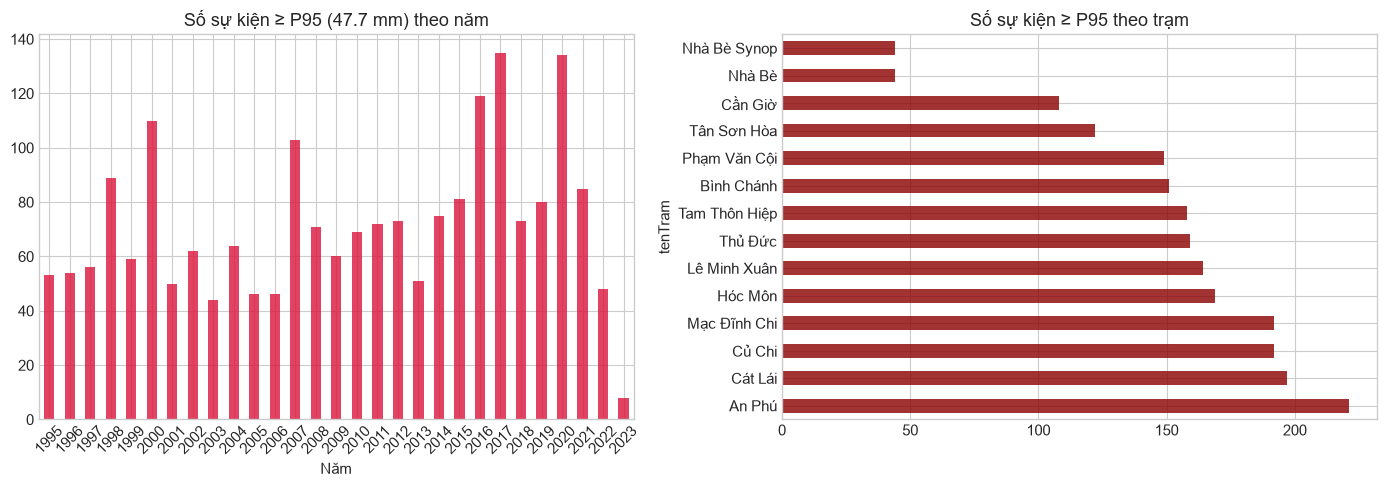


Tổng số sự kiện ≥ P95: 2,070 (5.00%)


In [36]:
# 7.2 Phân bố outliers theo năm & trạm (df_daily)
extreme = df_daily[df_daily['luongMua'] >= p95]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

extreme['year'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='crimson', alpha=0.8)
axes[0].set_title(f'Số sự kiện ≥ P95 ({p95:.1f} mm) theo năm')
axes[0].set_xlabel('Năm')
axes[0].tick_params(axis='x', rotation=45)

extreme['tenTram'].value_counts().plot(kind='barh', ax=axes[1], color='darkred', alpha=0.8)
axes[1].set_title('Số sự kiện ≥ P95 theo trạm')

plt.tight_layout()
plt.show()

print(f'\nTổng số sự kiện ≥ P95: {len(extreme):,} ({len(extreme)/len(df_daily)*100:.2f}%)')

#### Phân tích các sự kiện mưa cực đoan (Lượng mưa $\ge P95$)

**Quan sát**

* **Top các trận mưa kỷ lục trong lịch sử:**
* **Trận bão Usagi (25–26/11/2018):** Đóng góp tới 9 vị trí trong Top 20 trận mưa lớn nhất. Trạm **Tân Sơn Hòa** lập kỷ lục tuyệt đối với **$401.0\text{ mm}$** vào ngày 25/11/2018, theo sau là **Tam Thôn Hiệp** ($317.8\text{ mm}$), **Cần Giờ** ($290.8\text{ mm}$), và **Cát Lái** ($282.8\text{ mm}$).
* **Trận mưa lịch sử ngập trung tâm (26/09/2016):** Trạm **Mạc Đĩnh Chi** ghi nhận **$206.6\text{ mm}$**, trận mưa ngập diện rộng nổi tiếng toàn thành phố.
* **Mưa trái mùa cực đoan:** Trạm **Lê Minh Xuân** ghi nhận lượng mưa kỷ lục bất thường vào giai đoạn đầu năm như $248.2\text{ mm}$ (01/04/2017) và $222.3\text{ mm}$ (02/02/2017).


* **Biến động số sự kiện cực đoan ($\ge P95 = 47.7\text{ mm}$) theo thời gian:**
* Các năm ghi nhận tần suất xuất hiện mưa cực đoan cao đột biến bao gồm: **2017** ($> 135$ sự kiện), **2020** ($\approx 134$ sự kiện), **2016** ($\approx 120$ sự kiện), và **2000** ($110$ sự kiện).
* Giai đoạn 2016–2021 chứng kiến số đợt mưa cực đoan duy trì ở mức rất cao so với trung bình các năm 1995–2015.


* **Phân bố sự kiện cực đoan theo trạm:**
* **An Phú** là trạm ghi nhận nhiều sự kiện mưa cực đoan nhất toàn hệ thống ($> 220$ sự kiện), tiếp theo là **Cát Lái**, **Củ Chi**, và **Mạc Đĩnh Chi** (đều dao động quanh mốc $190 - 200$ sự kiện).
* Hai trạm **Nhà Bè** và **Nhà Bè Synop** có số lượng sự kiện $\ge P95$ thấp nhất ($< 50$ sự kiện), hoàn toàn tương thích với dữ liệu bản ghi ngắn và lượng mưa trung bình thấp đã phân tích trước đó.



**Insight**

* **Sự áp đảo của bão Usagi (2018):** Đợt thiên tai cuối tháng 11/2018 không chỉ gây ra trận mưa đơn lẻ lớn nhất lịch sử ($401\text{ mm}$ tại Tân Sơn Hòa) mà còn là đợt mưa lớn trên diện rộng toàn TP.HCM, khiến đồng loạt nhiều trạm đạt đỉnh lịch sử trong cùng một khoảng thời gian.
* **Nguy cơ mưa cực đoan gia tăng ở vùng ven và trung tâm:** Dù trạm **An Phú** và **Cát Lái** không sở hữu kỷ lục $401\text{ mm}$ nhưng lại có tần suất lặp lại mưa cực đoan ($\ge 47.7\text{ mm}$) cao nhất. Điều này cho thấy nguy cơ ngập lụt tại các khu vực Đông / Bắc TP.HCM diễn ra thường xuyên hơn so với các vùng phía Nam.
* **Hiện tượng bất thường thời tiết (2016–2020):** Sự bùng nổ số lượng sự kiện cực đoan trong giai đoạn 2016–2020 phản ánh rõ tác động của biến đổi khí hậu và hiện tượng El Niño/La Niña chuyển pha mạnh, làm tăng tần suất các đợt mưa dầm diện rộng và mưa rào với cường độ lớn.

---
## 8. Data Quality by Source & Period

=== So sánh thống kê theo nguồn (df_daily) ===


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
CCTL,33818.00,14.33,17.76,0.10,2.60,8.10,19.50,317.80
ĐKTTV,7550.00,12.67,18.29,0.10,1.40,5.80,16.80,401.00


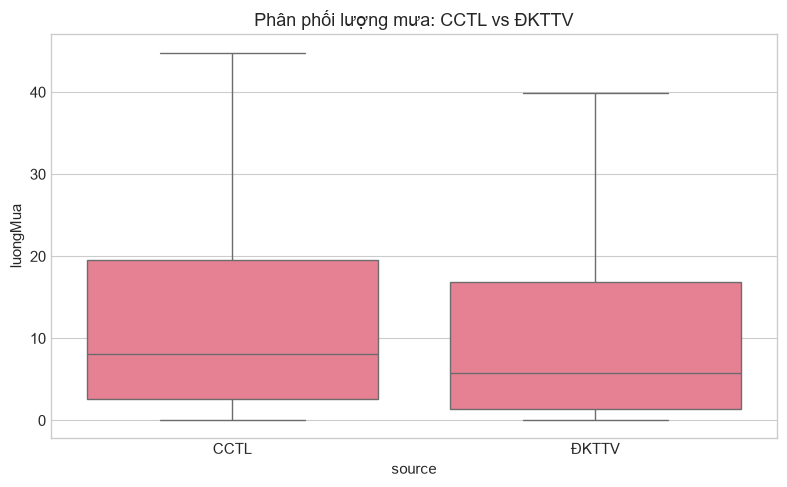

In [37]:
# 8.1 So sánh CCTL vs ĐKTTV (df_daily)
source_stats = df_daily.groupby('source')['luongMua'].describe()
print('=== So sánh thống kê theo nguồn (df_daily) ===')
display(source_stats.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_daily, x='source', y='luongMua', showfliers=False, ax=ax)
ax.set_title('Phân phối lượng mưa: CCTL vs ĐKTTV')
plt.tight_layout()
plt.show()

#### Phân bố lượng mưa giữa hai nguồn dữ liệu (CCTL vs ĐKTTV)

**Quan sát**

* **Nguồn CCTL (Chi cục Thủy lợi):**
* Giá trị trung vị (Median) nằm ở mức khoảng $8.0\text{ mm}$.
* Dải liên tứ phân vị (IQR) rộng hơn, kéo dài từ mốc $2.5\text{ mm}$ (Q1) đến $19.5\text{ mm}$ (Q3).
* Ria trên (Whisker) vươn tới mốc tiệm cận $45\text{ mm}$.


* **Nguồn ĐKTTV (Đài Khí tượng Thủy văn):**
* Giá trị trung vị nằm ở mức thấp hơn, đạt khoảng $5.8\text{ mm}$.
* Dải IQR hẹp hơn, kéo dài từ khoảng $1.2\text{ mm}$ (Q1) đến $16.8\text{ mm}$ (Q3).
* Ria trên dừng lại ở mốc $40\text{ mm}$.



**Insight**

* **Sự sai lệch giữa hai nguồn đo:** Dữ liệu từ nguồn **CCTL** có xu hướng ghi nhận mức lượng mưa nền cao hơn (trung vị $8.0\text{ mm}$ so với $5.8\text{ mm}$) và độ phân tán lớn hơn so với nguồn **ĐKTTV**.
* **Đặc tính trạm và phương pháp đo:** Sự khác biệt này có thể bắt nguồn từ vị trí địa lý của các trạm thuộc từng hệ thống (ví dụ: nguồn ĐKTTV quản lý các trạm như Tân Sơn Hòa, Mạc Đĩnh Chi ở nội thành, trong khi CCTL quản lý nhiều trạm vùng ven/ngoại thành như Phạm Văn Cội, Cát Lái - những nơi có lượng mưa trung bình cao hơn) hoặc do sự chênh lệch trong thiết bị/tần suất ghi nhận của hai cơ quan.
* **Xử lý dữ liệu đầu vào:** Khi hợp nhất dữ liệu từ cả hai nguồn để xây dựng mô hình bài toán, cần cân nhắc chuẩn hóa (normalization) hoặc thêm biến giả (dummy variable/feature flags) định danh nguồn dữ liệu (`source`) để tránh làm nhiễu mô hình do sự sai lệch hệ thống giữa hai nguồn này.

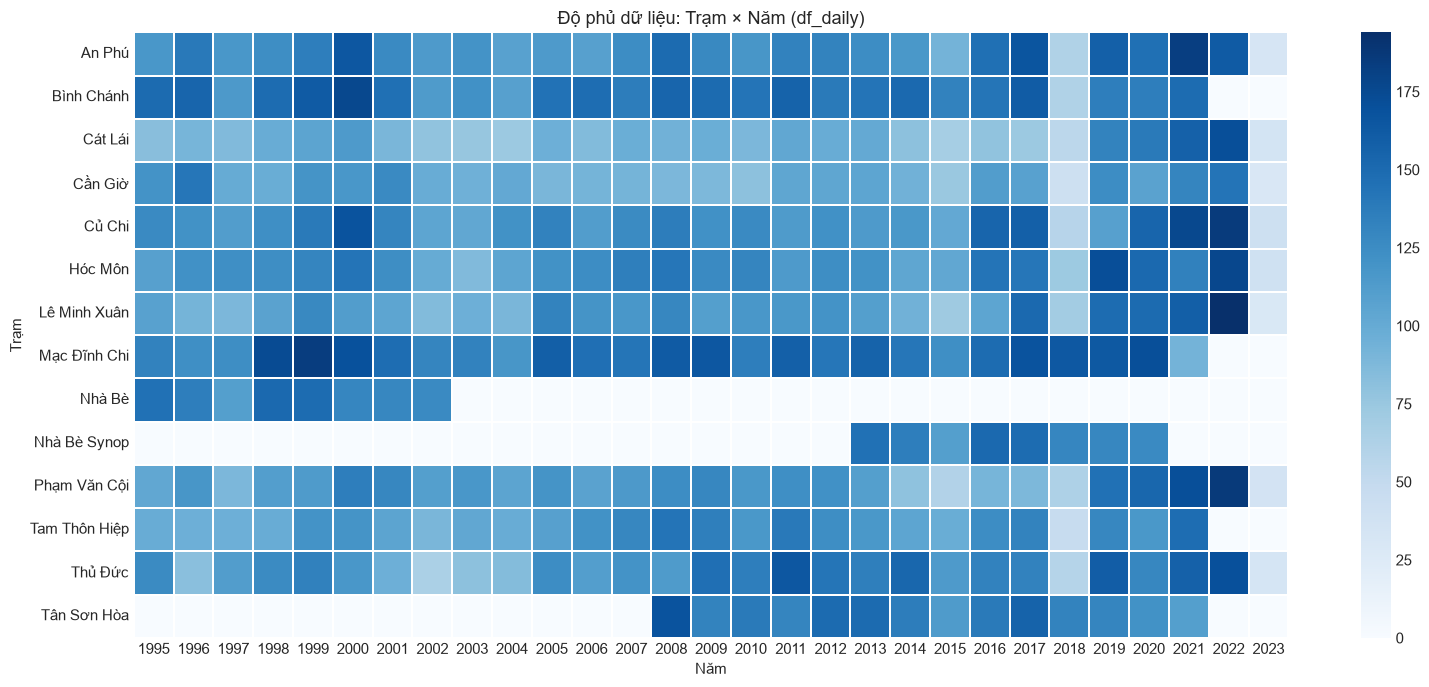

In [38]:
# 8.2 Coverage theo trạm × năm (df_daily)
coverage = df_daily.groupby(['tenTram', 'year']).size().unstack(fill_value=0)

plt.figure(figsize=(16, 7))
sns.heatmap(coverage, cmap='Blues', linewidths=0.2)
plt.title('Độ phủ dữ liệu: Trạm × Năm (df_daily)')
plt.xlabel('Năm')
plt.ylabel('Trạm')
plt.tight_layout()
plt.show()

#### Độ phủ dữ liệu theo Trạm và Năm (df_daily)

**Quan sát**

* **Tính liên tục của các trạm nòng cốt:**
* Phần lớn các trạm như **An Phú**, **Bình Chánh**, **Cát Lái**, **Củ Chi**, **Hóc Môn**, **Lê Minh Xuân**, **Mạc Đĩnh Chi**, **Phạm Văn Cội**, **Tam Thôn Hiệp**, và **Thủ Đức** duy trì độ phủ dữ liệu xuyên suốt 28 năm (1995–2022).
* Giai đoạn năm **2000** và giai đoạn **2019–2022** ghi nhận mật độ bản ghi dày đặc nhất (ô màu xanh đậm, nhiều năm đạt $> 150$ bản ghi/trạm).
* Năm **2018** và năm **2023** đồng loạt có màu xanh rất nhạt across hầu hết các trạm, thể hiện số lượng bản ghi sụt giảm đáng kể.


* **Sự thay thế giữa hai trạm trùng lặp (Nhà Bè vs Nhà Bè Synop):**
* Trạm **Nhà Bè** chỉ ghi nhận dữ liệu từ năm **1995 đến 2002** (sau đó trống hoàn toàn).
* Trạm **Nhà Bè Synop** xuất hiện và bắt đầu ghi nhận dữ liệu từ năm **2013 đến 2021**.


* **Trạm bắt đầu hoạt động muộn:**
* Trạm **Tân Sơn Hòa** hoàn toàn không có dữ liệu ở giai đoạn 1995–2007 (ô trắng) và chỉ bắt đầu ghi nhận liên tục từ năm **2008 đến 2021**.



**Insight**

* **Bản chất của sự cố dữ liệu năm 2018 & 2023:**
* Năm **2018** sụt giảm độ phủ là do thiếu hụt bản ghi rải rác ở một số tháng mùa khô.
* Năm **2023** nhạt màu là do dữ liệu mới chỉ cập nhật đến tháng 6/2023.


* **Xác nhận quá trình bàn giao/đổi tên trạm Nhà Bè:** Biểu đồ độ phủ chỉ rõ trạm **Nhà Bè** (cũ) ngưng hoạt động sau năm 2002, và được tái lập/thay thế dưới tên **Nhà Bè Synop** từ năm 2013. Cần lưu ý khoảng trống dữ liệu giai đoạn 2003–2012 của khu vực Nhà Bè khi phân tích chuỗi thời gian vùng Nam TP.HCM.
* **Chiến lược làm sạch dữ liệu (Data Cleaning):**
* Đối với **Tân Sơn Hòa**: Cần lọc bỏ giai đoạn 1995–2007 khi đưa trạm này vào các mô hình so sánh đa trạm theo thời gian thực.
* Đối với **Nhà Bè & Nhà Bè Synop**: Có thể tiến hành hợp nhất (merge) hai chuỗi này thành một trạm duy nhất mang tên **Nhà Bè**, chấp nhận khoảng hẫng dữ liệu 10 năm (2003–2012).

In [39]:
# 8.3 Kiểm tra năm 2022
print('=== Phân tích năm 2022 ===')

df_2022_daily  = df_daily[df_daily['year'] == 2022]
df_2022_hourly = df_hourly[df_hourly['year'] == 2022]

print(f'df_daily  2022: {len(df_2022_daily):,} dòng')
print(f'df_hourly 2022: {len(df_2022_hourly):,} dòng')

print('\nTheo trạm (df_daily 2022):')
print(df_2022_daily['tenTram'].value_counts())

print('\nTheo trạm (df_hourly 2022):')
print(df_2022_hourly['tenTram'].value_counts())

=== Phân tích năm 2022 ===
df_daily  2022: 1,388 dòng
df_hourly 2022: 12,067 dòng

Theo trạm (df_daily 2022):
tenTram
Lê Minh Xuân    194
Phạm Văn Cội    186
Củ Chi          185
Hóc Môn         177
Cát Lái         171
Thủ Đức         170
An Phú          162
Cần Giờ         143
Name: count, dtype: int64

Theo trạm (df_hourly 2022):
tenTram
Lê Minh Xuân    1600
Cần Giờ         1574
Củ Chi          1561
Phạm Văn Cội    1542
Thủ Đức         1505
An Phú          1498
Cát Lái         1418
Hóc Môn         1369
Name: count, dtype: int64


#### Phân tích cấu trúc dữ liệu năm 2022 (df_daily vs df_hourly)

**Quan sát**

* **Quy mô dữ liệu toàn hệ thống:**
* Năm 2022 ghi nhận **$1.388$ dòng** ở bảng dữ liệu ngày (`df_daily`) và **$12.067$ dòng** ở bảng dữ liệu giờ (`df_hourly`).
* Tỷ lệ bản ghi giữa `df_hourly` và `df_daily` đạt xấp xỉ $8.7 : 1$, cho thấy dữ liệu giờ chưa phản ánh đủ $24$ giờ/ngày cho mọi ngày có mưa mà chủ yếu tập trung ghi nhận các khung giờ phát sinh mưa.


* **Phân bố theo trạm ở bảng Ngày (`df_daily`):**
* **Lê Minh Xuân** dẫn đầu với số ngày ghi nhận mưa nhiều nhất ($194$ ngày), theo sau kề sát là **Phạm Văn Cội** ($186$ ngày) và **Củ Chi** ($185$ ngày).
* **Cần Giờ** có số ngày ghi nhận mưa ít nhất trong danh sách ($143$ ngày).
* Chỉ còn **8 trạm** xuất hiện trong danh sách dữ liệu năm 2022 (vắng mặt các trạm như Tân Sơn Hòa, Mạc Đĩnh Chi, Bình Chánh, Nhà Bè, Tam Thôn Hiệp).


* **Phân bố theo trạm ở bảng Giờ (`df_hourly`):**
* **Lê Minh Xuân** tiếp tục đứng đầu về số lượng bản ghi giờ ($1.600$ bản ghi).
* **Cần Giờ** có sự bứt phá mạnh mẽ ở dữ liệu giờ: đứng thứ 2 toàn hệ thống với $1.574$ bản ghi (dù ở `df_daily` xếp cuối bảng).
* **Hóc Môn** xếp cuối bảng dữ liệu giờ với $1.369$ bản ghi (trong khi ở `df_daily` xếp vị trí thứ 4).



**Insight**

* **Mất cân bằng giữa tần suất ngày và mật độ giờ (Cần Giờ vs Hóc Môn):**
* Trạm **Cần Giờ** chỉ có $143$ ngày mưa nhưng lại đóng góp tới $1.574$ bản ghi giờ ($\approx 11$ bản ghi/ngày mưa). Điều này phản ánh đặc điểm thời tiết vùng ven biển: **ít ngày mưa hơn nhưng mỗi đợt mưa kéo dài nhiều giờ**.
* Ngược lại, trạm **Hóc Môn** có tới $177$ ngày mưa nhưng chỉ đạt $1.369$ bản ghi giờ ($\approx 7.7$ bản ghi/ngày mưa), cho thấy hiện tượng **mưa rào nhanh, dứt hạt sớm** đặc trưng của vùng nội thành/tây bắc.


* **Sự thu hẹp mạng lưới trạm quan trắc (Data Truncation):** Việc dữ liệu năm 2022 chỉ còn ghi nhận tại 8 trạm (thuộc nguồn CCTL) khẳng định các trạm thuộc nguồn ĐKTTV (như Tân Sơn Hòa, Mạc Đĩnh Chi) đã dừng cập nhật hoặc không được tích hợp trong đợt thu thập này. Cần lưu ý sự đứt gãy này khi phân tích chuỗi thời gian liên tục 1995–2022.

---
## 9. Key Insights & Recommendations

### Tóm tắt Insights chính

**1. Cấu trúc dữ liệu sau cleaning**
- Tách thành 2 DataFrame:
  - `df_daily` (~41k dòng): daily gốc + hourly đã groupby sum theo trạm–ngày → dùng cho xu hướng, mùa vụ, so sánh trạm, outliers.
  - `df_hourly` (~14k dòng): dữ liệu giờ gốc, giữ cột `gio` → dùng cho phân tích cường độ mưa theo giờ.
- Đã loại: `toaDoX/toaDoY` (toàn 0), `capTram` (NaN ~94%), `ghiChu` (đã map thành `source`).
- Feature hỗ trợ: `season`, `is_rainy_season`, `decade`, `source` (CCTL / ĐKTTV), `is_hourly`.

**2. Phân phối lượng mưa**
- Lệch phải mạnh (right-skewed): median thấp, mean cao hơn, max lên tới hàng trăm mm.
- Không có giá trị 0 (có thể đã lọc ngày không mưa) → khi model cần cân nhắc zero-inflation / rain occurrence riêng.
- Outliers và extreme events tập trung mùa mưa; ngưỡng P95/P99 hữu ích cho cảnh báo.

**3. Tính mùa vụ rõ**
- Mùa mưa chính: tháng 5–11 (đỉnh thường tháng 9–10).
- Mùa khô: tháng 1–3 rất ít mưa.
- Feature `is_rainy_season` / `month` / `season` nên dùng trong mọi model có thành phần thời gian.

**4. Khác biệt giữa trạm & không gian**
- Số bản ghi và mức mưa TB khác nhau rõ giữa các trạm → không so sánh “tổng thô” giữa trạm.
- Coverage không đều: một số trạm (Tân Sơn Hòa) bắt đầu muộn; Nhà Bè vs Nhà Bè Synop có khoảng trống 2003–2012.
- Tọa độ dùng `kinhDo` / `viDo` cho spatial model / interpolation.

**5. Chất lượng & nguồn dữ liệu**
- CCTL: chủ yếu daily, giai đoạn dài.
- ĐKTTV: chi tiết hơn, nhiều hourly ở năm gần đây.
- Năm 2022: mật độ hourly rất cao; chỉ còn ~8 trạm trong mạng lưới → đứt gãy so với giai đoạn trước.
- Năm 2023: dữ liệu mới tới ~tháng 6 → không dùng để kết luận cả năm.

**6. Rủi ro thiên lệch nếu xử lý sai**
- Gộp hourly + daily rồi tính mean/sum theo năm sẽ làm các năm gần đây “phình” vì ghi nhiều lần/ngày, không phải vì mưa nhiều hơn.
- So sánh trạm không chuẩn hóa theo số ngày quan trắc sẽ sai.

---

### Đề xuất Data Preprocessing (trước khi model)

| Bước | Việc cần làm | Lý do |
|------|----------------|------|
| 1 | Luôn tách / chọn đúng `df_daily` hoặc `df_hourly` theo bài toán | Tránh lẫn độ phân giải |
| 2 | Chuẩn hóa theo trạm: mean/median theo ngày có mưa, hoặc rate (mm/ngày quan trắc) | Trạm có số record khác nhau |
| 3 | Xử lý gap: đánh dấu missing theo (trạm, ngày); không fill 0 bừa | 0 ≠ “không mưa” nếu ngày đó không được quan trắc |
| 4 | Hợp nhất Nhà Bè + Nhà Bè Synop (nếu cần chuỗi dài khu vực Nam) | Cùng khu vực, đổi tên/giai đoạn |
| 5 | Lọc Tân Sơn Hòa từ năm bắt đầu có data ổn định | Tránh bias giai đoạn trống |
| 6 | Log-transform hoặc dùng model cho skewed data (Gamma, Tweedie, Quantile) | Phân phối lệch phải mạnh |
| 7 | Tạo feature thời gian: month, season, is_rainy_season, lag 1–7 ngày, rolling mean | Seasonality + persistence |
| 8 | Tạo feature không gian: khoảng cách tới trạm khác, hoặc grid/IDW | Spatial correlation |
| 9 | Tách train/test theo thời gian (không random split) | Tránh leakage xu hướng dài hạn |
| 10 | Extreme: gắn nhãn vượt P95/P99 hoặc Peak-over-Threshold | Bài toán cảnh báo mưa lớn |

---

### Đề xuất hướng Modeling

**A. Dự báo lượng mưa ngắn hạn (ngày / giờ)**
- Baseline: seasonal naive, regression với month + station + lag.
- ML: XGBoost / LightGBM (feature tabular: thời gian, trạm, lag, rolling).
- Deep: LSTM / Temporal Fusion Transformer trên chuỗi theo trạm (cần align theo ngày, xử lý missing).
- Hourly: chỉ train trên `df_hourly`; có thể aggregate sau nếu cần daily forecast.

**B. Mưa cực đoan / rủi ro ngập**
- Extreme Value Theory: GEV hoặc Peak-over-Threshold trên `df_daily` (theo trạm hoặc theo vùng).
- Classification: vượt ngưỡng P95/P99 (imbalance → dùng scale_pos_weight / focal loss).
- Kết hợp không gian: xác suất mưa lớn theo cụm trạm gần nhau.

**C. Không gian – bản đồ mưa**
- Interpolation: IDW hoặc Ordinary Kriging từ `kinhDo`/`viDo` + `luongMua` (theo ngày hoặc trung bình tháng).
- Output: raster / heatmap phục vụ dashboard cảnh báo.

**D. Sản phẩm dữ liệu**
- Dashboard: mưa real-time / gần real-time theo trạm + so với ngưỡng lịch sử.
- API hoặc bảng daily đã chuẩn hóa (1 dòng = 1 trạm × 1 ngày) để team model dùng thống nhất.

---

### Nguyên tắc vàng khi làm tiếp

1. **Không gộp `df_daily` và `df_hourly`** khi tính thống kê mô tả hoặc train model trừ khi đã aggregate rõ ràng.
2. **Mọi so sánh theo năm / theo trạm** phải đi kèm mật độ quan trắc (count) hoặc chỉ dùng ngày đã quan trắc.
3. **Train/test theo thời gian**; giữ lại 2022–2023 làm test cẩn thận vì thay đổi mạng lưới và độ chi tiết.
4. **Document nguồn (CCTL vs ĐKTTV)** trong mọi bảng trung gian để giải thích break-point quanh giai đoạn chuyển nguồn.

Notebook EDA này là nền tảng để: (1) pipeline preprocessing chuẩn daily/hourly, (2) model dự báo & extreme, (3) lớp spatial / dashboard giám sát mưa TP.HCM.

---


#### 1. Dự báo ngắn hạn (Dự báo lượng mưa sắp trút xuống)

Mục tiêu của tầng này là đoán trước lượng mưa ($mm$) trong $1 - 3$ giờ tới tại các khu vực để làm đầu vào cho bài toán ngập.

* **Dùng Baseline theo mùa:** Làm bộ lọc tối thiểu. Nếu dự báo từ AI kém hơn mức trung bình mùa, hệ thống sẽ báo lỗi dữ liệu.
* **Dùng XGBoost / LightGBM (Mô hình chính vận hành hàng ngày):**
* *Ứng dụng:* Nhập dữ liệu mưa $1 - 3$ giờ trước, độ ẩm, khung giờ trong ngày, tháng trong năm.
* *Đầu ra:* Dự báo lượng mưa trong $1 - 3$ giờ tới cho từng trạm với tốc độ xử lý tính bằng mili-giây, rất phù hợp cho hệ thống cảnh báo thời gian thực (Real-time).


* **Dùng LSTM / TFT (Mô hình nâng cao cho đợt mưa kéo dài):**
* *Ứng dụng:* Khi phát hiện có dấu hiệu áp thấp/bão (dựa trên chuỗi mưa tăng liên tục nhiều giờ), kích hoạt TFT để dự báo diễn biến mưa dài hơn ($6 - 12$ giờ tới) giúp chính quyền có kịch bản ứng phó diện rộng.



---

#### 2. Mưa cực đoan (Đánh giá mức độ đe dọa & Bật chuông báo động)

Tầng này giúp mô hình không bị "sót" các trận mưa ngập sâu kỷ lục và cung cấp trọng số cho điểm rủi ro (*Risk Score*).

* **Dùng Phân loại vượt ngưỡng ($P95 / P99$):**
* *Ứng dụng:* Chạy song song một mô hình phân loại (XGBoost Classifier).
* *Đầu ra:* Trả về xác suất $0 - 100\%$ xem đợt mưa tới có vượt mốc $P95$ ($47.7\text{ mm}$) hoặc $P99$ ($81.2\text{ mm}$) hay không. Nếu xác suất $> 70\%$, hệ thống tự động **cộng ngay $30 - 50\%$ điểm vào Risk Score** mà không cần chờ tính toán độ sâu ngập.


* **Dùng GEV / POT (Thống kê chu kỳ ngập lịch sử):**
* *Ứng dụng:* Gắn "nhãn lịch sử" cho khu vực. Nếu trận mưa dự báo tiệm cận mức POT/GEV chu kỳ 10 năm ($> 200\text{ mm}$/ngày), hệ thống xác định đây là sự kiện thiên tai nghiêm trọng (như bão Usagi) và phát cảnh báo cấp độ cao nhất.



---

#### 3. Không gian (Phủ kín bản đồ ngập toàn thành phố)

Dữ liệu mưa chỉ có ở $\sim 10$ trạm, nhưng bạn cần cảnh báo ngập cho **từng phường/quận hoặc từng đoạn đường**.

* **Dùng IDW (Cho tính toán nhanh/Real-time):**
* *Ứng dụng:* Ngay khi XGBoost dự báo xong lượng mưa tại 10 trạm trong 1 giờ tới, dùng IDW để phủ lượng mưa tức thì lên toàn bộ các ô lưới (Grid $500\text{m} \times 500\text{m}$) trên bản đồ TP.HCM.


* **Dùng Kriging (Cho bản đồ nhiệt ngập lụt chính xác cao):**
* *Ứng dụng:* Kết hợp lượng mưa nội suy từ Kriging với **độ cao địa hình (DEM)** và **mật độ cống thoát nước** của từng phường để tính toán ra độ sâu nước ngập ($cm$) chính xác cho từng điểm nghẽn giao thông.
---


#### 4. Công thức **Risk Score (Điểm rủi ro ngập)** được thiết kế dựa trên khung đánh giá rủi ro thiên tai chuẩn quốc tế (UNDRR / IPCC), tách biệt rõ giữa **Nguy cơ thiên tai (Hazard)** và **Mức độ ảnh hưởng thực tế (Vulnerability & Exposure)**.


##### 4.1. Công thức tổng quát

$$\text{Risk Score} = S_{\text{Hazard}} \times S_{\text{Vulnerability}}$$

* **Thang điểm:** $0$ đến $100$ điểm.
* **Nguyên lý:** Nếu một khu vực ngập rất sâu ($S_{\text{Hazard}}$ cao) nhưng rơi vào lúc $2$ giờ sáng ở khu cánh đồng vắng ($S_{\text{Vulnerability}}$ thấp) thì Risk Score vẫn ở mức an toàn. Ngược lại, chỉ cần ngập nhẹ $15\text{ cm}$ nhưng rơi vào giao lộ lớn đúng giờ tan tầm, Risk Score sẽ bùng nổ lên mức báo động.

---

##### 4.2. Chi tiết từng thành phần trong công thức

A. $S_{\text{Hazard}}$ — Điểm nguy cơ ngập lụt ($0 - 100\%$)

Thành phần này đại diện cho **độ sâu và quy mô nước ngập** được tính toán từ các mô hình AI & Không gian:

$$S_{\text{Hazard}} = w_1 \cdot f(\text{Rain}_{\text{Kriging}}) + w_2 \cdot \text{DEM}_{\text{địa hình}} + w_3 \cdot \text{Triều cường}$$

* **$f(\text{Rain}_{\text{Kriging}})$ (Lượng mưa nội suy):** Lượng mưa dự báo ($mm$) trong $1 - 3$ giờ tới tại vị trí đó (nhờ mô hình XGBoost + Kriging).
* **$\text{DEM}_{\text{địa hình}}$ (Cao độ mặt đất):** Khu vực trũng thấp (ví dụ: Quận 7, Nhà Bè, Bình Chánh/Thủ Đức) sẽ bị cộng thêm điểm nguy cơ so với vùng đất cao (Củ Chi, Hóc Môn).
* **$\text{Triều cường}$ (Mức nước sông/kênh rạch):** Mưa lớn kết hợp triều cường đỉnh điểm làm cống không thể thoát nước, đẩy $S_{\text{Hazard}}$ lên tối đa.
* **$w_1, w_2, w_3$:** Các trọng số đóng góp (ví dụ: Mưa $50\%$, Địa hình $30\%$, Triều cường $20\%$).

---

B. $S_{\text{Vulnerability}}$ — Điểm mức độ ảnh hưởng & Nhạy cảm ($1.0 - 2.5$)

Thành phần này đóng vai trò là **Hệ số nhân phóng đại (Multiplier)** dựa trên ngữ cảnh thực tế:

$$S_{\text{Vulnerability}} = 1.0 + \Delta_{\text{Mưa cực đoan}} + \Delta_{\text{Giờ cao điểm}} + \Delta_{\text{Tuyến đường huyết mạch}}$$

1. **$\Delta_{\text{Mưa cực đoan}}$ (Báo động $P95 / P99$):**
* Nếu AI dự báo lượng mưa $< P95$ ($< 47.7\text{ mm}$): $\Delta = 0$
* Nếu lượng mưa $\ge P95$ ($47.7 - 81.2\text{ mm}$): Cộng thêm $+0.3$
* Nếu lượng mưa $\ge P99$ ($> 81.2\text{ mm}$ - nguy cơ thiên tai/bão Usagi): Cộng thêm $+0.6$


2. **$\Delta_{\text{Giờ cao điểm}}$ (Yếu tố thời gian tan tầm):**
* Khung giờ đêm/sáng sớm ($22\text{h} - 5\text{h}$): $\Delta = 0$
* Khung giờ bình thường ($6\text{h} - 15\text{h}$): $\Delta = +0.2$
* **Khung giờ vàng tan tầm ($15\text{h} - 19\text{h}$):** Cộng thêm $+0.5$ (do đây là đỉnh tần suất mưa đối lưu kết hợp mật độ xe cộ đông nhất).


3. **$\Delta_{\text{Tuyến đường huyết mạch}}$ (Yếu tố hạ tầng/giao thông):**
* Hẻm nhỏ / Khu dân cư thưa: $\Delta = 0$
* Đường trục chính / Ngã tư trọng điểm (như Cát Lái, Mạc Đĩnh Chi, Võ Văn Kiệt): Cộng thêm $+0.4$



---

##### 4.3. Ví dụ tính toán thực tế

**Kịch bản:** Chiều thứ 6, lúc **$16h30$** tại **Ngã tư Cát Lái**. AI dự báo đợt mưa chuẩn bị trút xuống đạt **$85\text{ mm}$** (vượt ngưỡng $P99$).

1. **Tính $S_{\text{Hazard}}$:**
* Mưa $85\text{ mm}$ + địa hình thấp ở Cát Lái $\rightarrow$ AI dự báo độ sâu ngập $35\text{ cm}$.
* Quy đổi ra điểm Nguy cơ ngập: $S_{\text{Hazard}} = 40$ điểm.


2. **Tính hệ số $S_{\text{Vulnerability}}$:**
* Mức cơ sở: $1.0$
* Lượng mưa $85\text{ mm} \ge P99$: $+0.6$
* Khung giờ $16\text{h}30$ (đỉnh giờ tan tầm): $+0.5$
* Vị trí nút giao Cát Lái (huyết mạch cảng/giao thông): $+0.4$
* $\rightarrow S_{\text{Vulnerability}} = 1.0 + 0.6 + 0.5 + 0.4 = 2.5$


3. **Kết quả Risk Score:**

$$\text{Risk Score} = 40 \times 2.5 = 100 \text{ điểm (BÁO ĐỘNG ĐỎ)}$$



$\rightarrow$ **Hành động hệ thống:** Phát Push Notification lập tức đến thoại di động người dân: *"Cảnh báo ngập sâu $>30\text{cm}$ tại Cát Lái trong 30 phút tới, khuyến cáo chuyển hướng lưu thông!"*